In [1]:
"""
LENDING CLUB LOAN DATA ANALYSIS
Enhanced Student Project Notebook
Deep Learning with Keras and TensorFlow

PROJECT GOAL
Build a deep learning model that predicts whether a loan will default,
using historical Lending Club loan data.

FILE NEEDED IN THE SAME FOLDER AS THIS NOTEBOOK
1. loan_data.csv

PROJECT RULES
1. Do not use for-loops.
2. Do not create user-defined functions.
3. Transform categorical values into numerical values before modeling.
4. Perform exploratory data analysis before building the model.
5. Check correlation between features and remove strongly correlated features.
6. Do not balance the full dataset before the train-test split.
7. Keep the test set untouched until final evaluation.

WHAT THIS PROJECT MUST COVER
1. Feature Transformation
   - Transform categorical values into numerical values.

2. Exploratory Data Analysis
   - Study different factors in the dataset.

3. Additional Feature Engineering
   - Check correlation between features.
   - Drop features that have a strong correlation.

4. Modeling
   - Build a deep learning model using Keras with TensorFlow backend.

FINAL DELIVERABLES
1. Evidence that the dataset was loaded correctly
2. Categorical feature transformation
3. Exploratory data analysis with meaningful plots
4. Target class distribution and imbalance check
5. Correlation analysis
6. Removal of strongly correlated features if needed
7. Prepared model-ready dataset
8. Deep learning classification model
9. Model evaluation using confusion matrix, classification report, sensitivity, and ROC-AUC
10. Final business interpretation
"""

# Column Rename Map
COLUMN_RENAME_MAP: dict[str, str] = {
    # Borrower Eligibility
    "credit.policy": "meets_credit_policy",  # 1 = passed LendingClub underwriting standards, 0 = did not
    # Loan Characteristics
    "purpose": "loan_purpose",  # self-reported reason for the loan (e.g. debt consolidation, credit card)
    "int.rate": "interest_rate",  # annual interest rate assigned to the loan — higher = riskier borrower
    "installment": "monthly_installment",  # fixed monthly repayment amount in USD
    # Borrower Financials
    "log.annual.inc": "log_annual_income",  # natural log of borrower's annual income — log-transformed to reduce skew
    "dti": "debt_to_income_ratio",  # total monthly debt / gross monthly income — higher = more financially stretched
    # Credit Profile
    "fico": "fico_score",  # credit score at application time (300–850) — strongest repayment predictor
    "days.with.cr.line": "days_with_credit_line",  # how long the borrower has had an open credit line — proxy for credit maturity
    "revol.bal": "revolving_balance",  # total outstanding balance across all revolving accounts (e.g. credit cards) in USD
    "revol.util": "revolving_utilization",  # revolving balance / credit limit (%) — high values signal financial stress
    "inq.last.6mths": "inquiries_last_6months",  # number of hard credit inquiries in the last 6 months — signals credit-seeking behavior
    "delinq.2yrs": "delinquencies_last_2years",  # times borrower was 30+ days past due in the last 2 years — payment reliability signal
    "pub.rec": "public_records",  # number of derogatory public records (bankruptcies, liens) — even 1 is a strong risk flag
    # Target Variable
    "not.fully.paid": "is_defaulted",  # 1 = loan was not fully repaid (default/charge-off), 0 = fully repaid — classification target
}


def print_qa(question: str, answer: str) -> None:
    bold = "\033[1m"
    green = "\033[92m"
    reset = "\033[0m"
    print(f"{bold}{question}{reset}")
    print(f"{green}{answer}{reset}\n")


In [2]:
# ============================================================
# SECTION 1. IMPORT THE REQUIRED LIBRARIES
# ============================================================
from typing import cast

# Core data handling
import numpy as np  # numerical operations and array math
import pandas as pd  # load and manipulate data in DataFrames
import matplotlib.pyplot as plt  # create plots and visualizations
import seaborn as sns  # statistical data visualization
from IPython.display import display  # display data in an interactive way

# Model training and evaluation
from sklearn.model_selection import train_test_split  # split data into train and test sets
from sklearn.preprocessing import StandardScaler  # normalize features to zero mean and unit variance

from sklearn.metrics import (
    confusion_matrix,  # show TP, TN, FP, FN counts
    classification_report,  # show precision, recall, F1 scores
    roc_auc_score,  # measure model discrimination ability with a single score
    roc_curve,  # get the points to draw the ROC curve
)

# Handle imbalanced classes
from imblearn.under_sampling import RandomUnderSampler  # downsample majority class to balance the dataset

# Deep learning with Keras and TensorFlow
import tensorflow as tf  # backend compute engine
from keras.models import Sequential  # stack layers in sequence
from keras.layers import (
    Dense,
    Dropout,
    InputLayer,
)  # Dense is a fully connected layer, Dropout prevents overfitting, Input Layer
from keras.metrics import Recall, AUC  # track these metrics during training
from keras.callbacks import EarlyStopping  # stop training when validation performance plateaus
# Plotting

In [3]:
# ============================================================
# SECTION 2. LOAD THE DATA
# ============================================================

# Question 1
# Load loan_data.csv into a DataFrame named loan_data.
#
# Then:
# - Display the first 5 rows
# - Display the shape of the dataset
# - Display the column names
# - Display the data types


dataset_path = "loan_data.csv"
loan_data = pd.read_csv(dataset_path)

print("First 5 rows of the dataset")
display(loan_data.head(5))

print("\nShape of the dataset")
print(loan_data.shape)

print("\nColumn names")
print(loan_data.columns.tolist())

print("\nData types")
print(loan_data.dtypes)

First 5 rows of the dataset


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0



Shape of the dataset
(9578, 14)

Column names
['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']

Data types
credit.policy          int64
purpose               object
int.rate             float64
installment          float64
log.annual.inc       float64
dti                  float64
fico                   int64
days.with.cr.line    float64
revol.bal              int64
revol.util           float64
inq.last.6mths         int64
delinq.2yrs            int64
pub.rec                int64
not.fully.paid         int64
dtype: object



Unique values in not.fully.paid
[0 1]

Summary statistics
13 Numeric columns: Index(['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti',
       'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='object')
1 Categorical columns: Index(['purpose'], dtype='object')


,count,mean,std,min,25%,50%,75%,max,skew
credit.policy,9578.0,0.804970,0.396245,0.000000,1.000000,1.000000,1.000000,1.000000e+00,-1.539621
int.rate,9578.0,0.122640,0.026847,0.060000,0.103900,0.122100,0.140700,2.164000e-01,0.164420
installment,9578.0,319.089413,207.071301,15.670000,163.770000,268.950000,432.762500,9.401400e+02,0.912522
log.annual.inc,9578.0,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,1.452835e+01,0.028668
dti,9578.0,12.606679,6.883970,0.000000,7.212500,12.665000,17.950000,2.996000e+01,0.023941
fico,9578.0,710.846314,37.970537,612.000000,682.000000,707.000000,737.000000,8.270000e+02,0.471260
days.with.cr.line,9578.0,4560.767197,2496.930377,178.958333,2820.000000,4139.958333,5730.000000,1.763996e+04,1.155748
revol.bal,9578.0,16913.963876,33756.189557,0.000000,3187.000000,8596.000000,18249.500000,1.207359e+06,11.161058
revol.util,9578.0,46.799236,29.014417,0.000000,22.600000,46.300000,70.900000,1.190000e+02,0.059985
inq.last.6mths,9578.0,1.577469,2.200245,0.000000,0.000000,1.000000,2.000000,3.300000e+01,3.584151


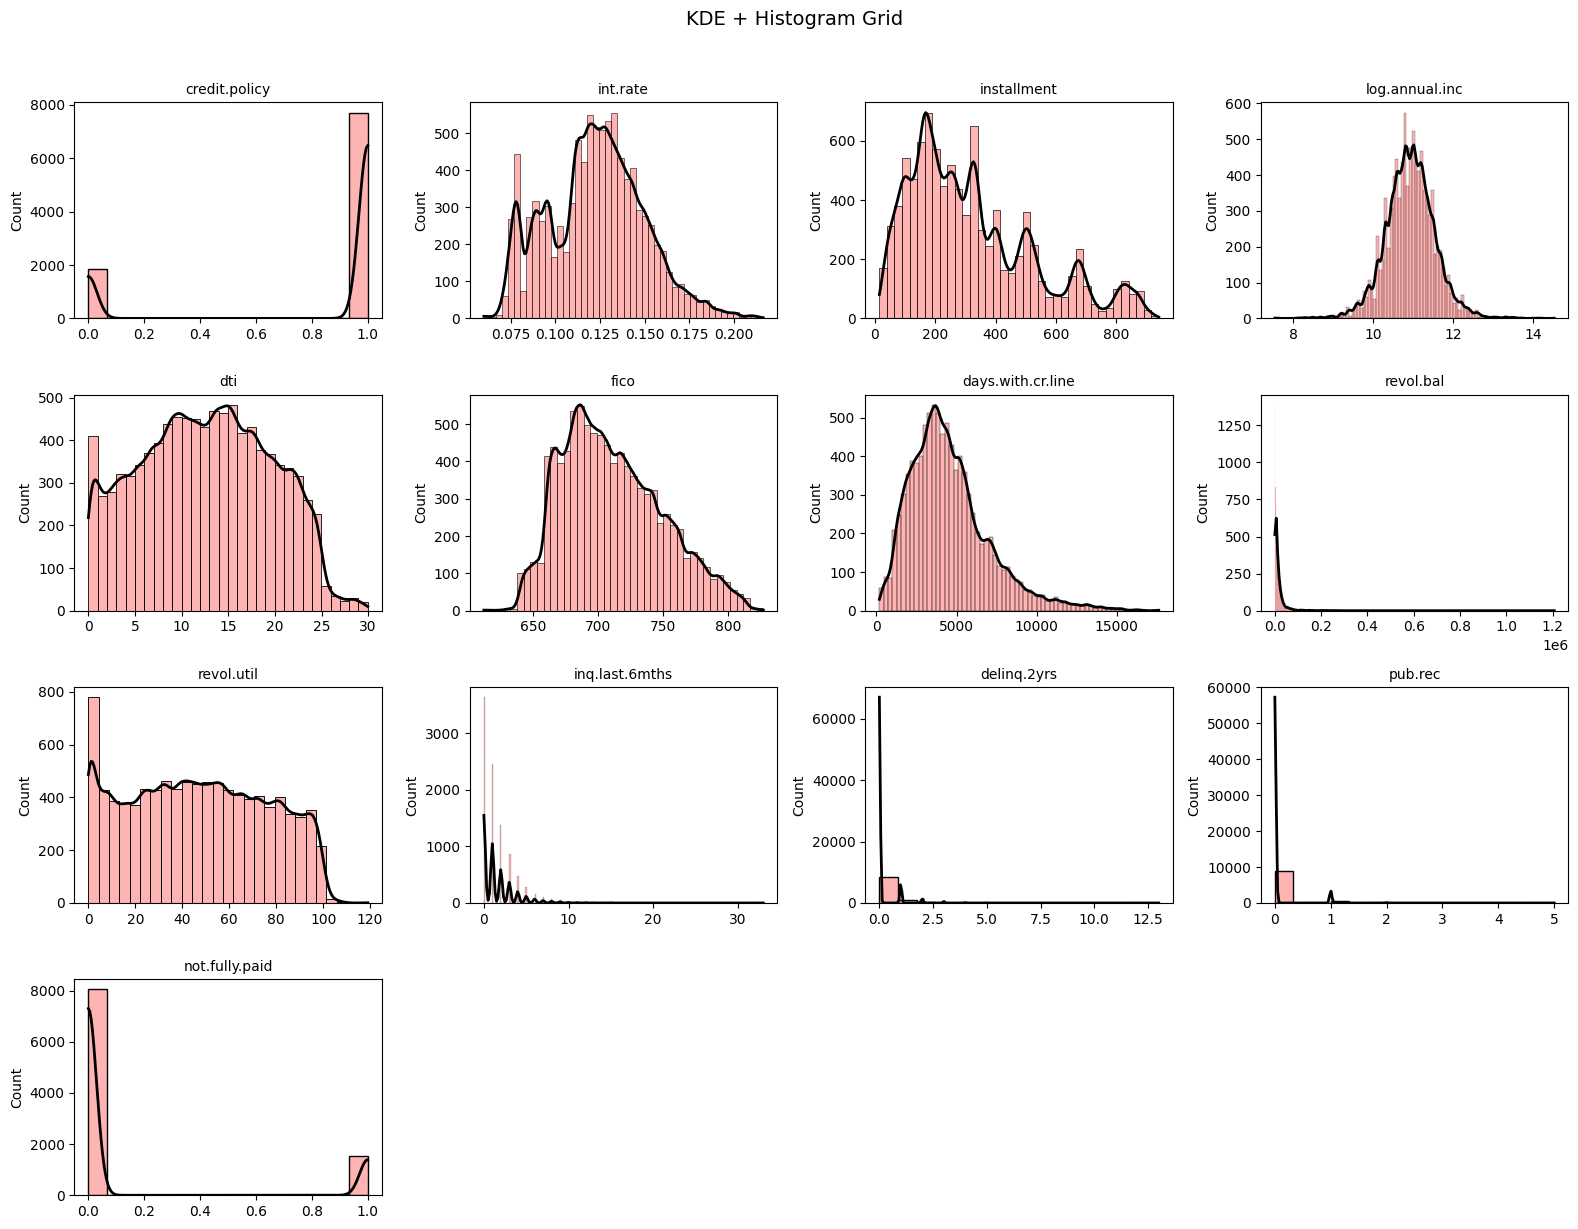


KDE + HISTOGRAM
credit.policy     Two spikes at 0 and 1, the spike at 1 is much taller, most borrowers passed
int.rate          Peaks around 11-13%, right tail trails off toward 22%, slightly skewed right
installment       Multimodal distribution with clear clusters, not evenly spread
log.annual.inc    Clean bell shape centered around 11, most borrowers earn a similar range
dti               Flat and spread out from 0 to 30, no single debt level dominates
fico              Smooth bell shape centered around 700, fewer borrowers at the extremes
days.with.cr.line Peaks around 3,000-4,000 days then drops off, most have moderate credit history
revol.bal         Highly right-skewed; heavy concentration near zero with a few extreme large balances
revol.util        Unusually flat from 0 to 100, people use very different amounts of their credit
inq.last.6mths    Massive spike at 0-2 then drops sharply, most had very few recent credit checks
delinq.2yrs       Almost entirely one tall spike at z

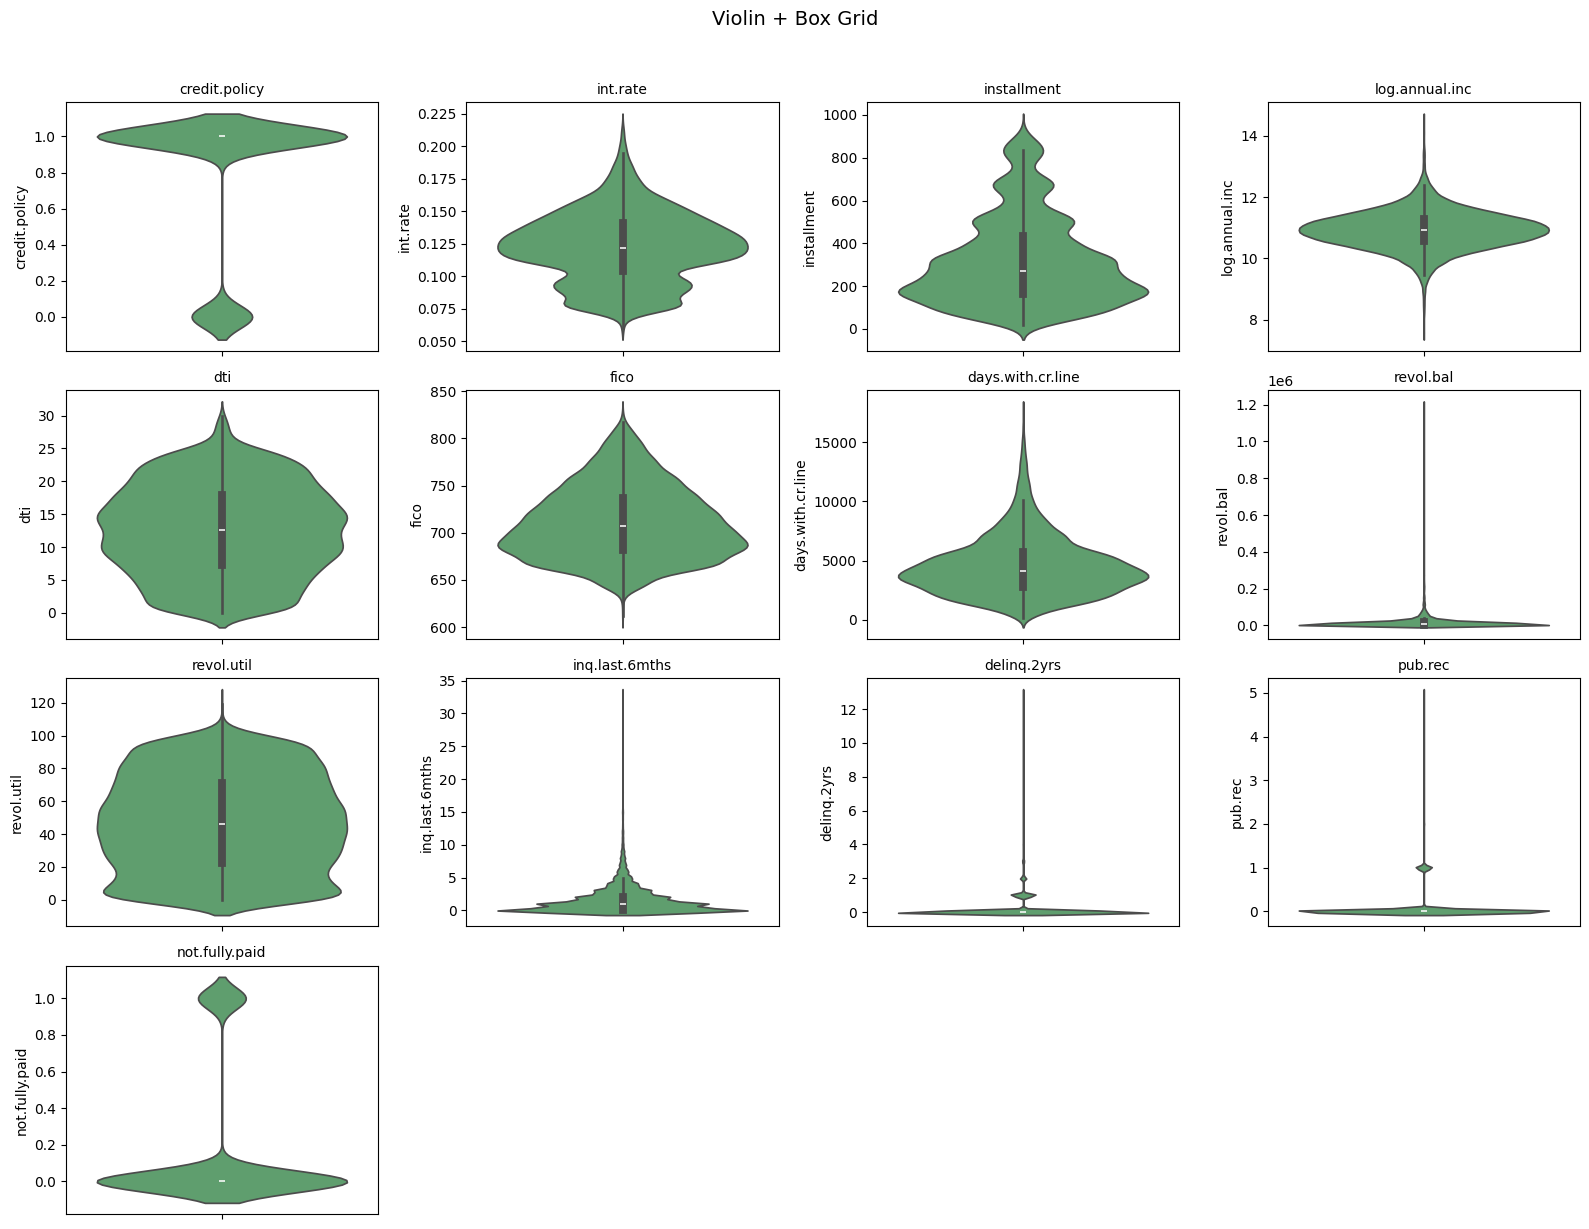


VIOLIN + BOX

credit.policy     Wide blob at 1 and tiny blob at 0, clearly behaves like a binary feature
int.rate          Narrow symmetric shape, rates are tightly packed between 10% and 15%
installment       Wide bumpy body with visible bulges, reflects the multiple payment clusters
log.annual.inc    Smooth hourglass shape, incomes concentrate in the middle range
dti               Wide flat body from top to bottom, debt levels are genuinely all over the place
fico              Triangle shape widest at 700, thinner at both ends, normal distribution confirmed
days.with.cr.line Wider at the bottom, thinner as it stretches upward, a few have very long history
revol.bal         Entire body squashed at zero, single long line shoots up to $1.2M
revol.util        Consistently wide from 0 to 100, almost perfectly rectangular, very uniform
inq.last.6mths    Tiny diamond near zero, single long whisker above confirms extreme outliers
delinq.2yrs       Nearly invisible body at zero, scattered do

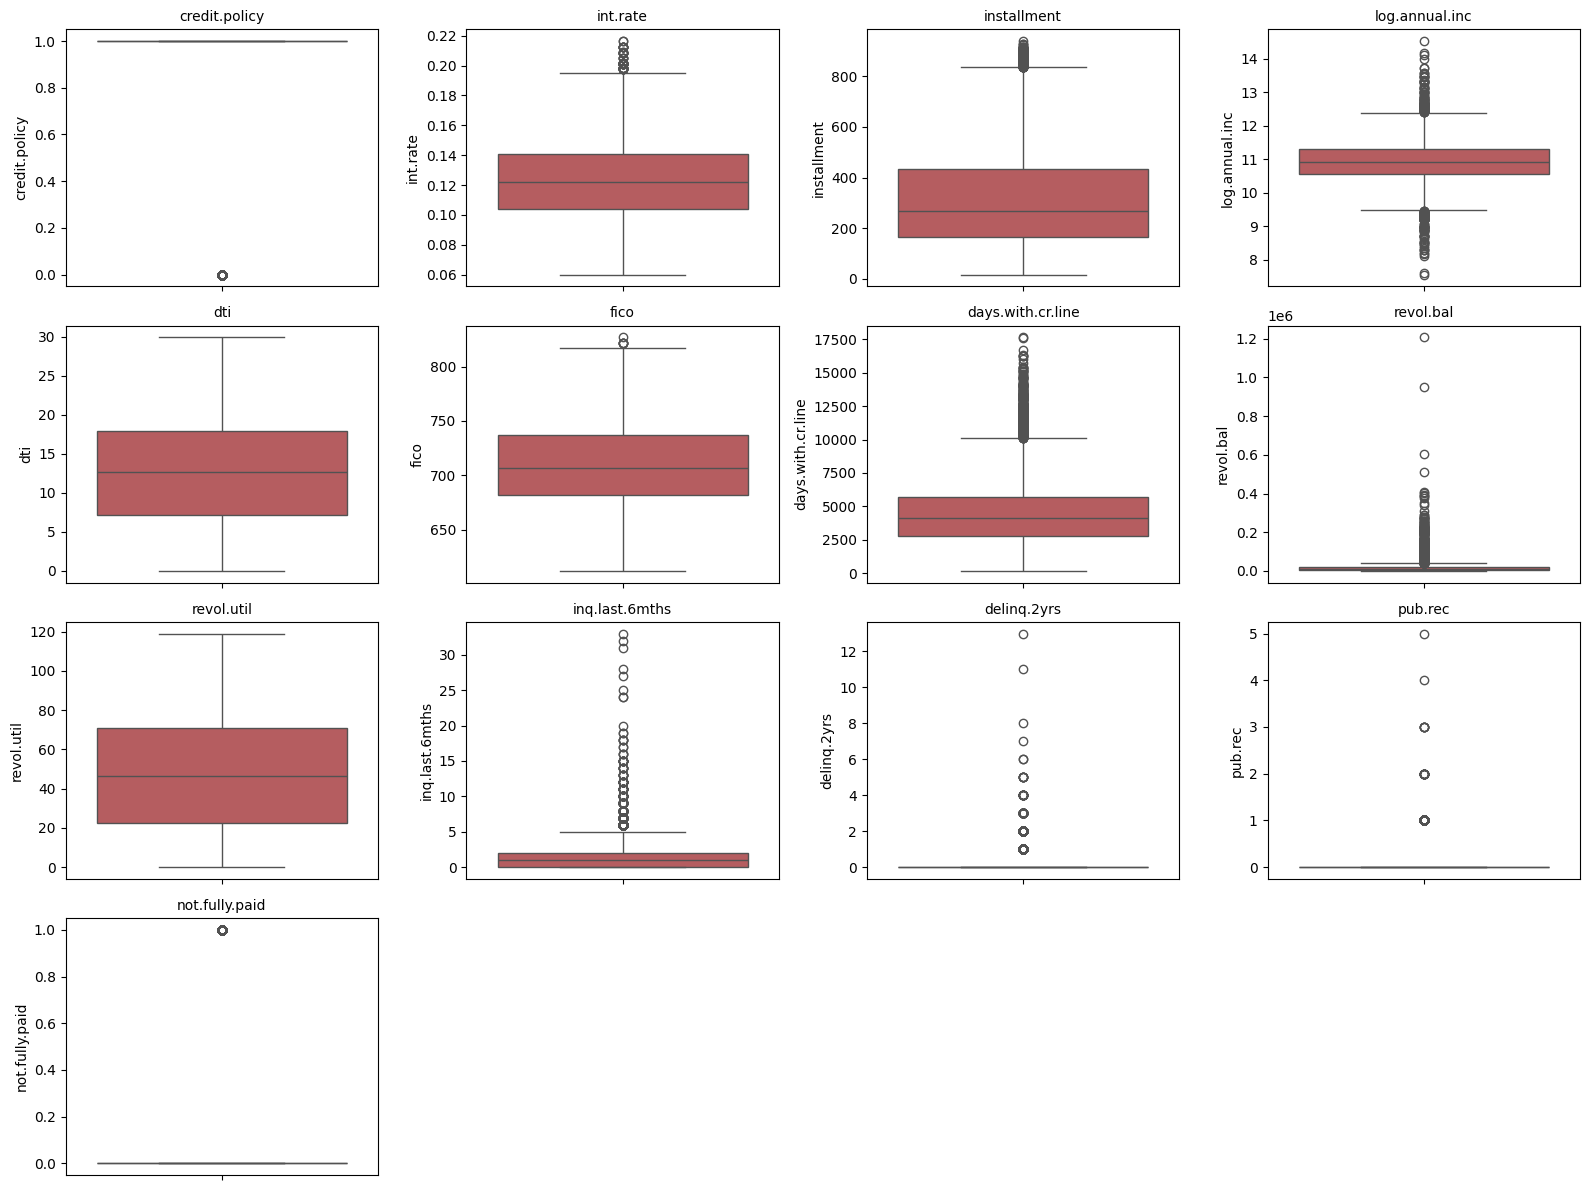


credit.policy     Box sits at 1 with one lonely dot at 0, practically a constant column
int.rate          Tight box from 10% to 14%, a cluster of dots above 18% are clear outliers
installment       Wide box from around $160 to $430, many dots above $700 worth investigating
log.annual.inc    Compact box around $40k-$80k range, a few dots below $10k and above $500k
dti               Balanced box from roughly 7% to 18%, whiskers reach 0 and 30%, no extreme dots
fico              Box from 682 to 737, one dot above 820 is a rare excellent-credit borrower
days.with.cr.line Box sits around 3,000-5,700 days, many dots above 10,000 days are genuine outliers
revol.bal         Box is invisible near zero, dots scatter all the way to $1.2M, serious outlier problem
revol.util        Wide box from 22% to 71%, whiskers reach 0 and 100%, a few go slightly above
inq.last.6mths    Box barely visible near 0-2, dozens of dots stacking up above 5 inquiries
delinq.2yrs       Box entirely at zero, dots scatt

In [ ]:
# ============================================================
# SECTION 3. INITIAL DATA EXPLORATION
# ============================================================

# Question 2
# Study the dataset by displaying:
# - Number of unique values in the target variable "not.fully.paid"
# - Summary statistics for numeric columns only
# - The purpose of numeric columns only
# - The names of categorical columns only
# - The names of numeric columns only


# Count unique values in the target column
unique_values_target = loan_data["not.fully.paid"].unique()

# Summary statistics for numeric columns only
numeric_columns = loan_data.select_dtypes(include="number").columns

# Summary statistics for numeric columns only
summary_stats = loan_data[numeric_columns].describe().T

# Calculate skewness
skewness = loan_data[numeric_columns].skew()

# Append skewness to the summary statistics
summary_stats["skew"] = skewness

# Identify categorical columns only
categorical_columns = loan_data.select_dtypes(include=["object", "category"]).columns

# Show results
print("\nUnique values in not.fully.paid")
print(unique_values_target)

print("\nSummary statistics")
print(f"{len(numeric_columns)} Numeric columns: {numeric_columns}")
print(f"{len(categorical_columns)} Categorical columns: {categorical_columns}")
display(summary_stats)
# Written answer:
# What does not.fully.paid = 0 mean?
# The borrower repaid the loan completely on time without missing payments.
#
# What does not.fully.paid = 1 mean?
# The borrower did not repay the loan fully. This includes defaults, charge-offs, or missed payments.

# # KDE + Histogram Grid
# Shows distribution shape and skewness per column

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    # Plot histogram with one color, then overlay KDE with different color
    sns.histplot(data=loan_data, x=col, kde=True, ax=axes[i], color="#FF6B6B", kde_kws={"bw_adjust": 0.5})
    # Change KDE line color separately by accessing the line
    for line in axes[i].lines:
        line.set_color("black")
        line.set_linewidth(2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

for i in range(len(numeric_columns), len(axes)):
    axes[i].set_visible(False)

plt.suptitle("KDE + Histogram Grid", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("""
KDE + HISTOGRAM
===============
credit.policy     Two spikes at 0 and 1, the spike at 1 is much taller, most borrowers passed
int.rate          Peaks around 11-13%, right tail trails off toward 22%, slightly skewed right
installment       Multimodal distribution with clear clusters, not evenly spread
log.annual.inc    Clean bell shape centered around 11, most borrowers earn a similar range
dti               Flat and spread out from 0 to 30, no single debt level dominates
fico              Smooth bell shape centered around 700, fewer borrowers at the extremes
days.with.cr.line Peaks around 3,000-4,000 days then drops off, most have moderate credit history
revol.bal         Highly right-skewed; heavy concentration near zero with a few extreme large balances
revol.util        Unusually flat from 0 to 100, people use very different amounts of their credit
inq.last.6mths    Massive spike at 0-2 then drops sharply, most had very few recent credit checks
delinq.2yrs       Almost entirely one tall spike at zero, late payments are very rare
pub.rec           Same as delinq, one tall spike at zero, bankruptcies or liens are very rare
not.fully.paid    Tall spike at 0 and small spike at 1, confirming 84% repaid vs 16% defaulted
""")


# Violin + Box Grid
# Shows shape, quartiles, and outliers per column

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.violinplot(y=loan_data[col], ax=axes[i], color="#55A868", inner="box")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

for j in range(len(numeric_columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Violin + Box Grid", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("""
VIOLIN + BOX
============

credit.policy     Wide blob at 1 and tiny blob at 0, clearly behaves like a binary feature
int.rate          Narrow symmetric shape, rates are tightly packed between 10% and 15%
installment       Wide bumpy body with visible bulges, reflects the multiple payment clusters
log.annual.inc    Smooth hourglass shape, incomes concentrate in the middle range
dti               Wide flat body from top to bottom, debt levels are genuinely all over the place
fico              Triangle shape widest at 700, thinner at both ends, normal distribution confirmed
days.with.cr.line Wider at the bottom, thinner as it stretches upward, a few have very long history
revol.bal         Entire body squashed at zero, single long line shoots up to $1.2M
revol.util        Consistently wide from 0 to 100, almost perfectly rectangular, very uniform
inq.last.6mths    Tiny diamond near zero, single long whisker above confirms extreme outliers
delinq.2yrs       Nearly invisible body at zero, scattered dots above are rare exceptions
pub.rec           Almost all at zero with a handful of dots reaching up to 5
not.fully.paid    Large blob at 0 and small blob at 1, visually confirms the class imbalance

""")


# Box Plot Grid
# Shows quartiles, median, and outliers cleanly per column

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(y=loan_data[col], ax=axes[i], color="#C44E52")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

for j in range(len(numeric_columns), len(axes)):
    axes[j].set_visible(False)

plt.title("Box Plot Grid", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("""
credit.policy     Box sits at 1 with one lonely dot at 0, practically a constant column
int.rate          Tight box from 10% to 14%, a cluster of dots above 18% are clear outliers
installment       Wide box from around $160 to $430, many dots above $700 worth investigating
log.annual.inc    Compact box around $40k-$80k range, a few dots below $10k and above $500k
dti               Balanced box from roughly 7% to 18%, whiskers reach 0 and 30%, no extreme dots
fico              Box from 682 to 737, one dot above 820 is a rare excellent-credit borrower
days.with.cr.line Box sits around 3,000-5,700 days, many dots above 10,000 days are genuine outliers
revol.bal         Box is invisible near zero, dots scatter all the way to $1.2M, serious outlier problem
revol.util        Wide box from 22% to 71%, whiskers reach 0 and 100%, a few go slightly above
inq.last.6mths    Box barely visible near 0-2, dozens of dots stacking up above 5 inquiries
delinq.2yrs       Box entirely at zero, dots scattered above up to 13 late payments
pub.rec           Box entirely at zero, dots rise to 5, each one a bankruptcy or lien event
not.fully.paid    Box at zero, single dot at 1 is the only hint of defaults in this view
""")


In [5]:
# ============================================================
# SECTION 4. CHECK FOR MISSING VALUES
# ============================================================

# Question 3
# Check whether the dataset contains missing values.
#
# Complete all of the following:
# - Count total missing values
# - Count missing values per column
# - State whether missing-value treatment is needed

total_missing_values = loan_data.isnull().sum().sum()

missing_values_per_column = loan_data.isnull().sum()

print("\nTotal missing values in the dataset")
print(total_missing_values)

print("\nMissing values per column")
print(missing_values_per_column)

# Written answer:
# Does this dataset contain missing values?
# No, there are no missing values in this dataset. All columns have complete data.
#
# Is missing-value imputation needed here?
# No, imputation is not needed since there are no missing values to handle.


Total missing values in the dataset
0

Missing values per column
credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64


In [6]:
# ============================================================
# SECTION 5. FEATURE TRANSFORMATION
# REQUIRED TASK 1. TRANSFORM CATEGORICAL VALUES INTO NUMERICAL VALUES
# ============================================================

# Question 4
# Identify the categorical feature and transform it into numeric columns.
#
# In this dataset, purpose is the categorical column.
#
# Complete all of the following:
# - Display the unique values in purpose
# - Create dummy variables for purpose
# - Confirm that the transformed dataset no longer contains raw text columns

print("\nUnique loan purposes")
print(loan_data["purpose"].unique())

loan_data_encoded = pd.get_dummies(loan_data, columns=["purpose"], drop_first=True, dtype=int)

print("\nFirst 5 rows after encoding")
display(loan_data_encoded.head())

print("\nData types after encoding")
print(loan_data_encoded.dtypes)

# Written answer:
# Why must purpose be transformed before building a neural network?
# Neural networks only understand numbers. Text like "debt_consolidation"
# means nothing to the model mathematically, so we convert each category
# into a binary column (0 or 1) that the network can actually compute with.
#
# What new columns were created from purpose?
# One binary column per unique purpose value, minus one (drop_first=True removes
# one category to avoid multicollinearity).


Unique loan purposes
['debt_consolidation' 'credit_card' 'all_other' 'home_improvement'
 'small_business' 'major_purchase' 'educational']

First 5 rows after encoding


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,1,0,0,0,0,0



Data types after encoding
credit.policy                   int64
int.rate                      float64
installment                   float64
log.annual.inc                float64
dti                           float64
fico                            int64
days.with.cr.line             float64
revol.bal                       int64
revol.util                    float64
inq.last.6mths                  int64
delinq.2yrs                     int64
pub.rec                         int64
not.fully.paid                  int64
purpose_credit_card             int64
purpose_debt_consolidation      int64
purpose_educational             int64
purpose_home_improvement        int64
purpose_major_purchase          int64
purpose_small_business          int64
dtype: object



Target counts
not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

Percentage of fully paid loans, not.fully.paid = 0
83.99%

Percentage of not fully paid loans, not.fully.paid = 1
16.01%


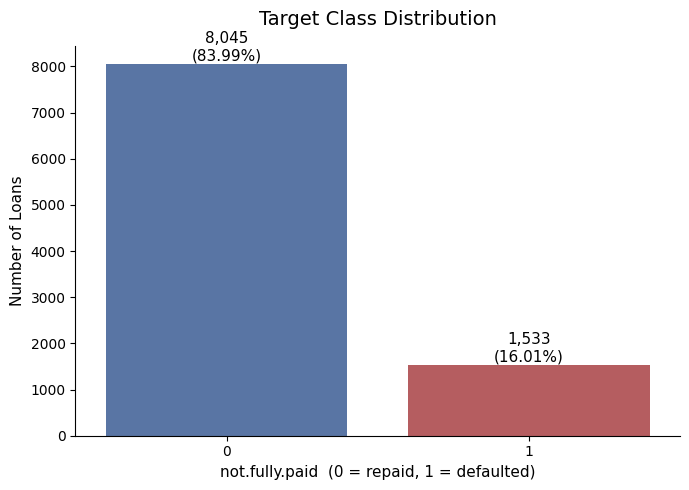

In [7]:
# ============================================================
# SECTION 6. CHECK TARGET CLASS BALANCE
# ============================================================

target_counts = loan_data_encoded["not.fully.paid"].value_counts().sort_index()

target_percentages = (target_counts / target_counts.sum() * 100).round(2)

print("\nTarget counts")
print(target_counts)

print("\nPercentage of fully paid loans, not.fully.paid = 0")
print(f"{target_percentages[0]}%")

print("\nPercentage of not fully paid loans, not.fully.paid = 1")
print(f"{target_percentages[1]}%")

plt.figure(figsize=(7, 5))

sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts.values,
    hue=target_counts.index.astype(str),
    palette=["#4C72B0", "#C44E52"],
    legend=False,
)

for i, (count, pct) in enumerate(zip(target_counts.values, target_percentages.values)):
    plt.text(i, count + 80, f"{count:,}\n({pct}%)", ha="center", fontsize=11)

plt.title("Target Class Distribution", fontsize=14, pad=15)
plt.xlabel("not.fully.paid  (0 = repaid, 1 = defaulted)", fontsize=11)
plt.ylabel("Number of Loans", fontsize=11)
plt.xticks(rotation=0)
sns.despine()  # remove plot borders
plt.tight_layout()
plt.show()

# Written answer:
# Is the dataset balanced or imbalanced?
# Imbalanced. Roughly 84% repaid and only 16% defaulted.
# For every default there are about 5 repaid loans in the dataset.
#
# Why can this be a problem for a default-prediction model?
# The model will lean toward predicting repaid almost every time because
# that is what it sees most during training. It will look accurate on paper
# but will miss most actual defaults, which is exactly what the bank needs to catch.


Default rate by purpose
purpose
small_business        27.786753
educational           20.116618
home_improvement      17.011129
all_other             16.602317
debt_consolidation    15.238817
credit_card           11.568938
major_purchase        11.212815
Name: not.fully.paid, dtype: float64


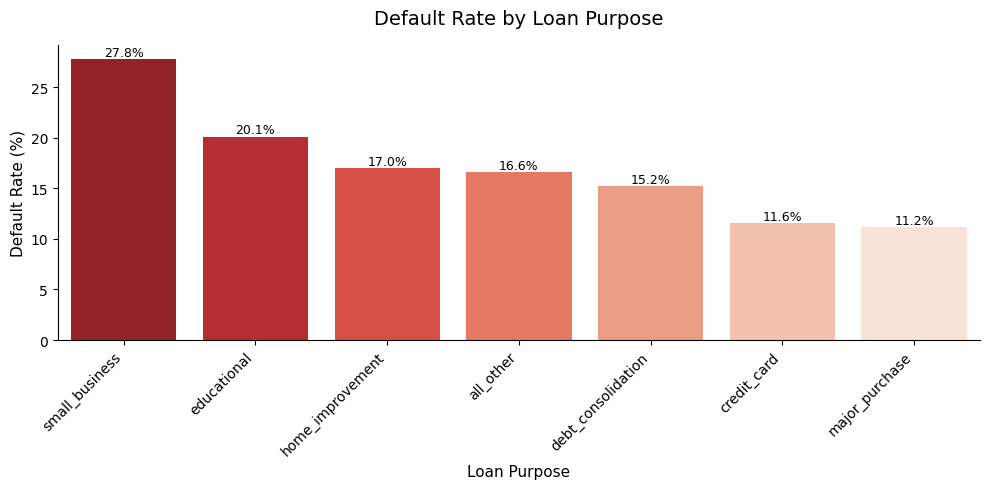

Which loan purpose appears to have the highest default rate?

Small business loans have the highest default rate by a noticeable margin.
This makes sense because small businesses carry more financial uncertainty
compared to personal loans like credit cards or debt consolidation.
    


Default rate by credit policy
credit.policy
0    27.783726
1    13.151751
Name: not.fully.paid, dtype: float64


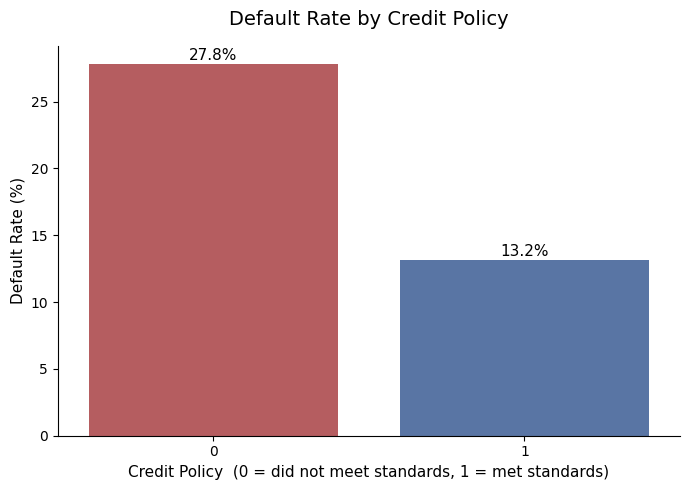

Which group has a higher default rate, credit.policy = 0 or credit.policy = 1?

Borrowers who did NOT meet credit standards (policy = 0) default at a higher rate.
This is expected. The credit check exists precisely to filter out risky borrowers.
What is interesting though is that policy = 1 borrowers still default at around 13%,
which tells us the credit check helps but is far from a perfect filter.
    



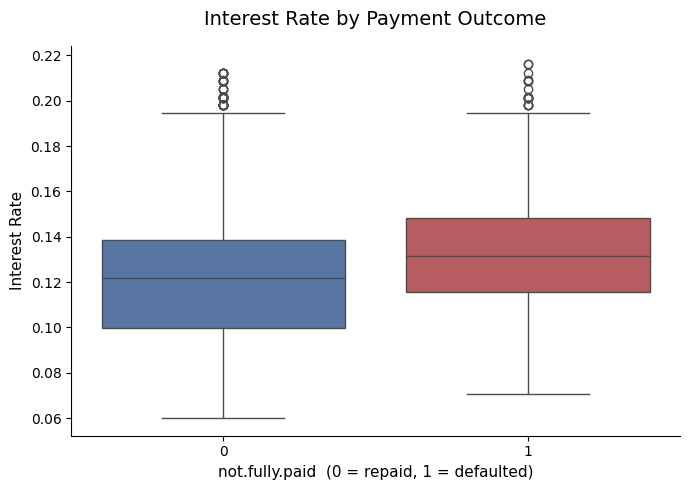

Do defaulted loans appear to have higher interest rates?

Yes, but the difference is modest.
Repaid loans (0) have a median around 12% with a wider spread from 10% to 14%.
Defaulted loans (1) have a median around 13% with a tighter spread from 12% to 15%.
Both groups share similar whiskers and outliers above 20%.
So interest rate alone is not a strong separator between the two groups,
the boxes overlap too much to rely on it as a standalone predictor.




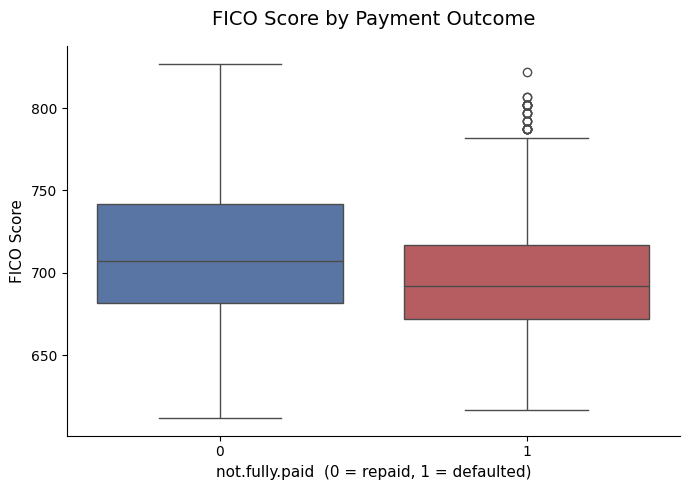

Do defaulted loans appear to have lower FICO scores?

Yes, and this is one of the clearest separations we have.
Repaid loans (0) have a noticeably higher median FICO score than defaulted loans (1).
The boxes overlap less compared to interest rate, meaning FICO score is a
stronger signal for separating the two groups.
Borrowers who defaulted tend to have lower credit scores going in,
which aligns with what FICO scores are designed to measure:
the likelihood that someone will repay their debts.
    



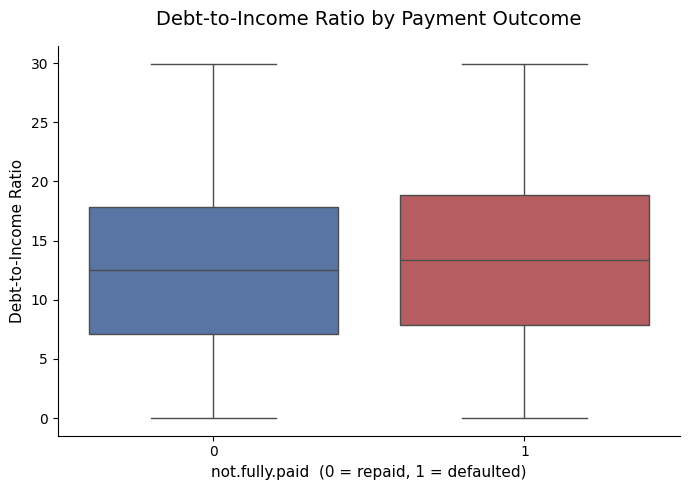

Does debt-to-income ratio appear different between the two groups?

The two boxes overlap heavily, meaning dti alone does not cleanly
separate repaid from defaulted loans.
Defaulted loans (1) show a slightly higher median dti, which makes
intuitive sense as borrowers already stretched thin financially are
more likely to miss payments when unexpected costs arise.
However the difference is small and the spread of both groups is
very similar, making dti a weak standalone predictor compared to
fico score which showed a much cleaner separation.




In [8]:
# ============================================================
# SECTION 7. EXPLORATORY DATA ANALYSIS OF DIFFERENT FACTORS
# REQUIRED TASK 2. EXPLORATORY DATA ANALYSIS
# ============================================================

# Question 6
# Explore how different factors relate to loan default.
#
# Create and interpret the following:
# 1. Default rate by loan purpose
# 2. Default rate by credit policy
# 3. Interest rate by payment outcome
# 4. FICO score by payment outcome
# 5. Debt-to-income ratio by payment outcome

# ----------------------------
# 6A. Default rate by purpose
# ----------------------------

default_rate_by_purpose = (loan_data.groupby("purpose")["not.fully.paid"].mean() * 100).sort_values(ascending=False)  # type: ignore

print("\nDefault rate by purpose")
print(default_rate_by_purpose)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=default_rate_by_purpose.index,
    y=default_rate_by_purpose.values,
    hue=default_rate_by_purpose.index,
    palette="Reds_r",
    legend=False,
)

for i, val in enumerate(default_rate_by_purpose.values):
    plt.text(i, val + 0.3, f"{val:.1f}%", ha="center", fontsize=9)

plt.title("Default Rate by Loan Purpose", fontsize=14, pad=15)
plt.xlabel("Loan Purpose", fontsize=11)
plt.ylabel("Default Rate (%)", fontsize=11)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

# Written interpretation:

print_qa(
    "Which loan purpose appears to have the highest default rate?",
    """
Small business loans have the highest default rate by a noticeable margin.
This makes sense because small businesses carry more financial uncertainty
compared to personal loans like credit cards or debt consolidation.
    """,
)


# ----------------------------
# 6B. Default rate by credit policy
# ----------------------------

default_rate_by_credit_policy = loan_data.groupby("credit.policy")["not.fully.paid"].mean() * 100  # type: ignore

print("\nDefault rate by credit policy")
print(default_rate_by_credit_policy)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=default_rate_by_credit_policy.index.astype(str),
    y=default_rate_by_credit_policy.values,
    hue=default_rate_by_credit_policy.index.astype(str),
    palette=["#C44E52", "#4C72B0"],
    legend=False,
)

for i, val in enumerate(default_rate_by_credit_policy.values):
    plt.text(i, val + 0.3, f"{val:.1f}%", ha="center", fontsize=11)

plt.title("Default Rate by Credit Policy", fontsize=14, pad=15)
plt.xlabel("Credit Policy  (0 = did not meet standards, 1 = met standards)", fontsize=11)
plt.ylabel("Default Rate (%)", fontsize=11)
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

# Written interpretation:
print_qa(
    "Which group has a higher default rate, credit.policy = 0 or credit.policy = 1?",
    """
Borrowers who did NOT meet credit standards (policy = 0) default at a higher rate.
This is expected. The credit check exists precisely to filter out risky borrowers.
What is interesting though is that policy = 1 borrowers still default at around 13%,
which tells us the credit check helps but is far from a perfect filter.
    """,
)

# ----------------------------
# 6C. Interest rate by payment outcome
# ----------------------------

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=loan_data, x="not.fully.paid", y="int.rate", hue="not.fully.paid", palette=["#4C72B0", "#C44E52"], legend=False
)

plt.title("Interest Rate by Payment Outcome", fontsize=14, pad=15)
plt.xlabel("not.fully.paid  (0 = repaid, 1 = defaulted)", fontsize=11)
plt.ylabel("Interest Rate", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

# Written interpretation:
print_qa(
    "Do defaulted loans appear to have higher interest rates?",
    """
Yes, but the difference is modest.
Repaid loans (0) have a median around 12% with a wider spread from 10% to 14%.
Defaulted loans (1) have a median around 13% with a tighter spread from 12% to 15%.
Both groups share similar whiskers and outliers above 20%.
So interest rate alone is not a strong separator between the two groups,
the boxes overlap too much to rely on it as a standalone predictor.
""",
)

# ----------------------------
# 6D. FICO score by payment outcome
# ----------------------------

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=loan_data, x="not.fully.paid", y="fico", hue="not.fully.paid", palette=["#4C72B0", "#C44E52"], legend=False
)

plt.title("FICO Score by Payment Outcome", fontsize=14, pad=15)
plt.xlabel("not.fully.paid  (0 = repaid, 1 = defaulted)", fontsize=11)
plt.ylabel("FICO Score", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

# Written interpretation:
print_qa(
    "Do defaulted loans appear to have lower FICO scores?",
    """
Yes, and this is one of the clearest separations we have.
Repaid loans (0) have a noticeably higher median FICO score than defaulted loans (1).
The boxes overlap less compared to interest rate, meaning FICO score is a
stronger signal for separating the two groups.
Borrowers who defaulted tend to have lower credit scores going in,
which aligns with what FICO scores are designed to measure:
the likelihood that someone will repay their debts.
    """,
)

# ----------------------------
# 6E. Debt-to-income ratio by payment outcome
# ----------------------------

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=loan_data, x="not.fully.paid", y="dti", hue="not.fully.paid", palette=["#4C72B0", "#C44E52"], legend=False
)

plt.title("Debt-to-Income Ratio by Payment Outcome", fontsize=14, pad=15)
plt.xlabel("not.fully.paid  (0 = repaid, 1 = defaulted)", fontsize=11)
plt.ylabel("Debt-to-Income Ratio", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

# Written interpretation:
print_qa(
    "Does debt-to-income ratio appear different between the two groups?",
    """
The two boxes overlap heavily, meaning dti alone does not cleanly
separate repaid from defaulted loans.
Defaulted loans (1) show a slightly higher median dti, which makes
intuitive sense as borrowers already stretched thin financially are
more likely to miss payments when unexpected costs arise.
However the difference is small and the spread of both groups is
very similar, making dti a weak standalone predictor compared to
fico score which showed a much cleaner separation.
""",
)



Correlation matrix


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
credit.policy,1.000000,-0.294089,0.058770,0.034906,-0.090901,0.348319,0.099026,-0.187518,-0.104095,-0.535511,-0.076318,-0.054243,0.003216,0.020193,-0.031346,0.006036,0.024281,-0.003511
int.rate,-0.294089,1.000000,0.276140,0.056383,0.220006,-0.714821,-0.124022,0.092527,0.464837,0.202780,0.156079,0.098162,-0.042109,0.123607,-0.019618,-0.050697,-0.068978,0.151247
installment,0.058770,0.276140,1.000000,0.448102,0.050202,0.086039,0.183297,0.233625,0.081356,-0.010419,-0.004368,-0.032760,0.000774,0.161658,-0.094510,0.023024,-0.079836,0.145654
log.annual.inc,0.034906,0.056383,0.448102,1.000000,-0.054065,0.114576,0.336896,0.372140,0.054881,0.029171,0.029203,0.016506,0.072942,-0.026214,-0.119799,0.116375,-0.031020,0.091540
dti,-0.090901,0.220006,0.050202,-0.054065,1.000000,-0.241191,0.060101,0.188748,0.337109,0.029189,-0.021792,0.006209,0.084476,0.179149,-0.035325,-0.092788,-0.077719,-0.069245
fico,0.348319,-0.714821,0.086039,0.114576,-0.241191,1.000000,0.263880,-0.015553,-0.541289,-0.185293,-0.216340,-0.147592,-0.012512,-0.154132,-0.013012,0.097474,0.067129,0.063292
days.with.cr.line,0.099026,-0.124022,0.183297,0.336896,0.060101,0.263880,1.000000,0.229344,-0.024239,-0.041736,0.081374,0.071826,0.046220,-0.009318,-0.042621,0.068087,-0.020561,0.034883
revol.bal,-0.187518,0.092527,0.233625,0.372140,0.188748,-0.015553,0.229344,1.000000,0.203779,0.022394,-0.033243,-0.031010,0.072316,0.005785,-0.034743,0.003258,-0.062395,0.083069
revol.util,-0.104095,0.464837,0.081356,0.054881,0.337109,-0.541289,-0.024239,0.203779,1.000000,-0.013880,-0.042740,0.066717,0.091321,0.211869,-0.053128,-0.114449,-0.108079,-0.060962
inq.last.6mths,-0.535511,0.202780,-0.010419,0.029171,0.029189,-0.185293,-0.041736,0.022394,-0.013880,1.000000,0.021245,0.072673,-0.033640,-0.044240,0.024243,0.043827,-0.001445,0.042567


<Figure size 1400x1000 with 0 Axes>

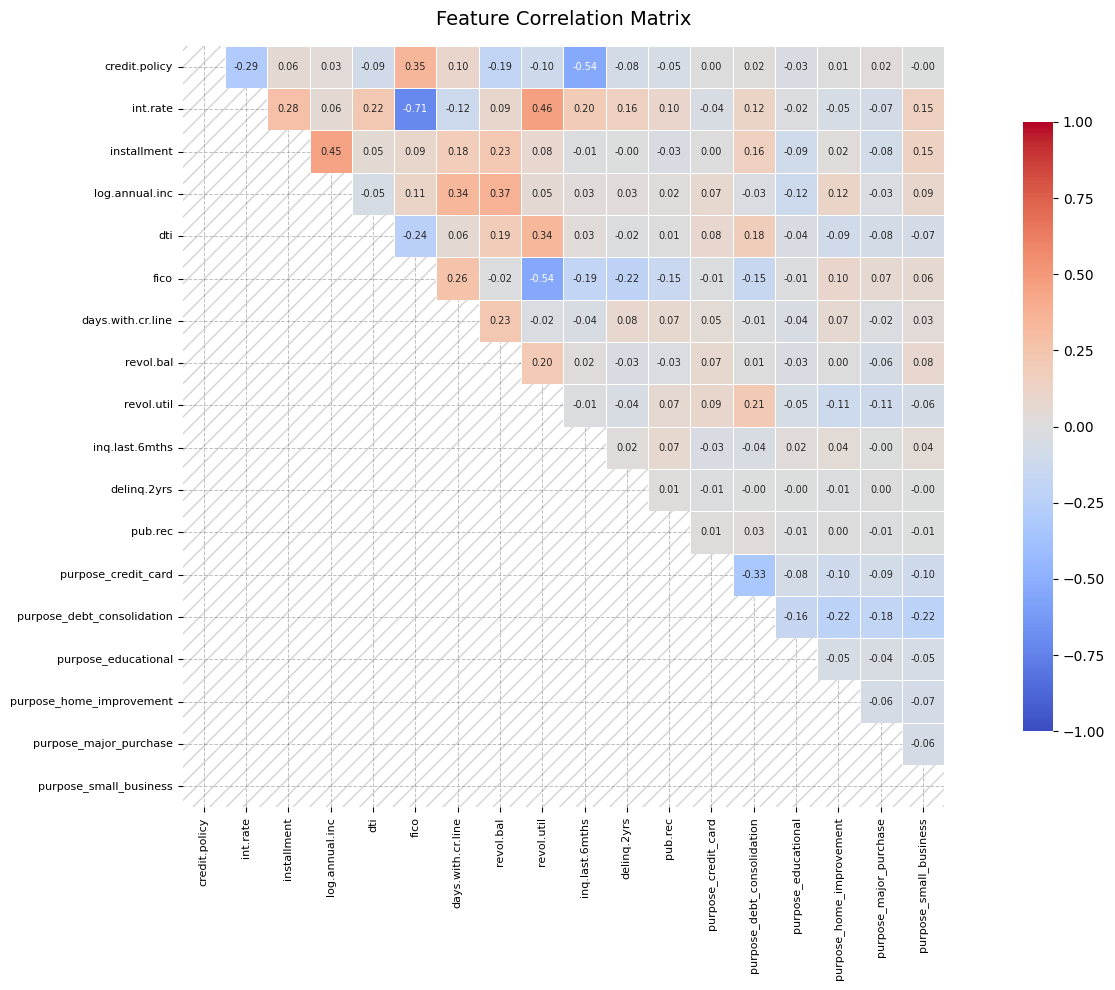


Strongly correlated features to consider dropping
[]

Shape before dropping strongly correlated features
(9578, 19)

Shape after dropping strongly correlated features
(9578, 19)

Which features were strongly correlated enough to drop?
Any feature pairs with absolute correlation above 0.80 get flagged and dropped. none are found the two shapes are identical. 

Why can dropping strongly correlated features help a model?
When two features are strongly correlated they are telling the model the same story twice. This is called multicollinearity. In a neural network this creates redundant weights that compete with each other during training, making the model less stable and harder to interpret. Removing one of the pair keeps the information while reducing noise, leading to cleaner and more efficient learning.



In [9]:
# ============================================================
# SECTION 8. ADDITIONAL FEATURE ENGINEERING
# REQUIRED TASK 3. CHECK CORRELATION AND DROP STRONGLY CORRELATED FEATURES
# ============================================================


# Question 7
# Check correlation between features and identify strongly correlated pairs.
#
# Complete all of the following:
# - Create a correlation matrix
# - Plot the correlation matrix
# - Build an upper-triangle correlation table
# - Identify features with absolute correlation above 0.80
# - Drop strongly correlated features if any are found
#
# Use only the predictor columns when deciding which features to drop.
# Do not include the target while deciding feature correlation.

from matplotlib import patches

correlation_matrix = loan_data_encoded.drop(columns=["not.fully.paid"]).corr()

print("\nCorrelation matrix")
display(correlation_matrix)

plt.figure(figsize=(14, 10))
mask = np.tril(np.ones(correlation_matrix.shape), k=0).astype(bool)

fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7},
    square=True,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1,
)

# Fill the masked lower triangle with a dashed pattern
n = len(correlation_matrix)
for i in range(n):
    for j in range(i + 1):
        ax.add_patch(
            patches.Rectangle(
                (j, i), 1, 1, fill=True, facecolor="white", edgecolor="lightgray", hatch="//", linewidth=0
            )
        )

# Draw dashed lines connecting each x-axis label to its column
for i in range(n):
    ax.plot([i + 0.5, i + 0.5], [n, i], color="gray", linewidth=0.7, linestyle="--", alpha=0.5, zorder=5)

# Draw dashed lines connecting each y-axis label to its row
for i in range(n):
    ax.plot(
        [0, i + 1],  # from left edge all the way to where the filled cells start
        [i + 0.5, i + 0.5],
        color="gray",
        linewidth=0.7,
        linestyle="--",
        alpha=0.5,
        zorder=5,
    )
plt.title("Feature Correlation Matrix", fontsize=14, pad=15)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

strongly_correlated_features = upper_triangle.columns[(upper_triangle.abs() > 0.80).any()].tolist()

print("\nStrongly correlated features to consider dropping")
print(strongly_correlated_features)

loan_data_final = loan_data_encoded.drop(columns=strongly_correlated_features)

print("\nShape before dropping strongly correlated features")
print(loan_data_encoded.shape)

print("\nShape after dropping strongly correlated features")
print(loan_data_final.shape)

print_qa(
    "\nWhich features were strongly correlated enough to drop?",
    "Any feature pairs with absolute correlation above 0.80 get flagged and dropped. "
    "none are found the two shapes are identical. ",
)

print_qa(
    "Why can dropping strongly correlated features help a model?",
    "When two features are strongly correlated they are telling the model the same story twice. "
    "This is called multicollinearity. In a neural network this creates redundant weights that "
    "compete with each other during training, making the model less stable and harder to interpret. "
    "Removing one of the pair keeps the information while reducing noise, "
    "leading to cleaner and more efficient learning.",
)

In [10]:
# ============================================================
# SECTION 9. SEPARATE FEATURES AND TARGET
# ============================================================

# Question 8
# Separate predictor features from the target.
#
# Complete all of the following:
# - Create X using all columns except not.fully.paid
# - Create y using not.fully.paid
# - Confirm the shapes of X and y

X = loan_data_final.drop(columns=["not.fully.paid"])

y = loan_data_final["not.fully.paid"]

print("\nShape of X")
print(X.shape)

print("\nShape of y")
print(y.shape)


Shape of X
(9578, 18)

Shape of y
(9578,)


In [11]:
# Question 9
# Split the data into training and testing sets.
#
# Complete all of the following:
# - Use 20% of the data for testing
# - Use random_state=42
# - Use stratify=y
# - Print target percentages in training and testing sets

X_train, X_test, y_train, y_test = cast(
    tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series],
    train_test_split(X, y, test_size=0.20, random_state=42, stratify=y),
)
print("\nTraining target percentages before balancing")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target percentages")
print((y_test.value_counts(normalize=True) * 100).round(2))

print_qa(
    "\nWhy should the split happen before balancing?",
    """
    The test set is supposed to represent the real world, and in the real world
    loan defaults are genuinely rare. Only about 16% of borrowers actually default.
    So if we balance the data first and then split, our test set ends up with a
    50/50 mix that simply does not exist in reality. We would then evaluate the
    model on a fantasy dataset and get metrics that look great on paper but fall
    apart the moment the model sees real loan applications.

    By splitting first, the test set stays frozen at the original 84/16 distribution
    and gives us an honest and realistic measure of how the model would actually
    perform in production. The balancing then only happens on the training set,
    where we want the model to learn defaults more aggressively without polluting
    the evaluation.
    """,
)


Training target percentages before balancing
not.fully.paid
0    84.0
1    16.0
Name: proportion, dtype: float64

Testing target percentages
not.fully.paid
0    83.98
1    16.02
Name: proportion, dtype: float64

Why should the split happen before balancing?

    The test set is supposed to represent the real world, and in the real world
    loan defaults are genuinely rare. Only about 16% of borrowers actually default.
    So if we balance the data first and then split, our test set ends up with a
    50/50 mix that simply does not exist in reality. We would then evaluate the
    model on a fantasy dataset and get metrics that look great on paper but fall
    apart the moment the model sees real loan applications.

    By splitting first, the test set stays frozen at the original 84/16 distribution
    and gives us an honest and realistic measure of how the model would actually
    perform in production. The balancing then only happens on the training set,
    where we want the model 


Training target counts before balancing
not.fully.paid
0    6436
1    1226
Name: count, dtype: int64

Training target counts after balancing
not.fully.paid
0    1226
1    1226
Name: count, dtype: int64


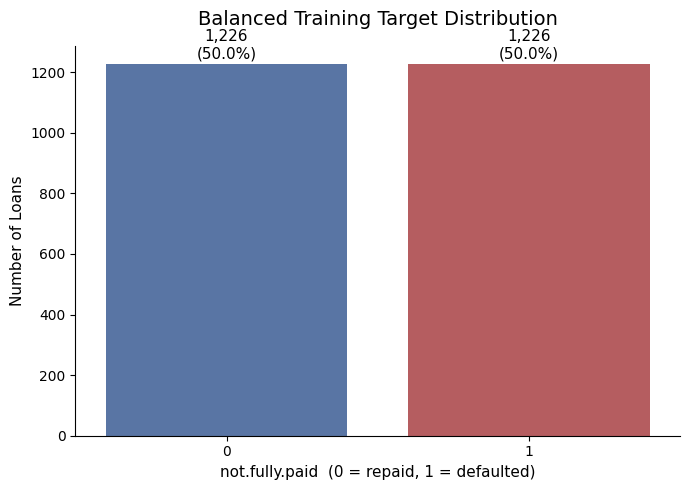

Why should the test set remain unbalanced and untouched?

    The test set represents the real world, and in the real world only 16% of
    borrowers default. Balancing it would mean testing the model on conditions
    that simply do not exist in production, making our metrics look better than
    they actually are. Keeping it untouched gives us an honest picture of how
    the model truly performs on real loan applications.
    



In [12]:
# ============================================================
# SECTION 11. BALANCE ONLY THE TRAINING DATA
# ============================================================

# Question 10
# Because the target is imbalanced, balance only the training set.
#
# Complete all of the following:
# - Show training counts before balancing
# - Apply RandomUnderSampler
# - Show training counts after balancing
# - Plot the balanced training target distribution


print("\nTraining target counts before balancing")
print(y_train.value_counts())

undersampler = RandomUnderSampler(random_state=42)

X_train_balanced, y_train_balanced = cast(
    tuple[pd.DataFrame, pd.Series],
    undersampler.fit_resample(X_train, y_train),
)


print("\nTraining target counts after balancing")
# save value count in a vairable
y_train_count = y_train_balanced.value_counts()
balanced_counts: pd.Series = y_train_balanced.value_counts().sort_index()

print(balanced_counts)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=balanced_counts.index.astype(str),
    y=balanced_counts.values,
    hue=balanced_counts.index.astype(str),
    palette=["#4C72B0", "#C44E52"],
    legend=False,
)

for i, (count, pct) in enumerate(
    zip(balanced_counts.values, (y_train_balanced.value_counts(normalize=True) * 100).values)
):
    plt.text(i, count + 20, f"{count:,}\n({pct:.1f}%)", ha="center", fontsize=11)

plt.title("Balanced Training Target Distribution", fontsize=14, pad=15)
plt.xlabel("not.fully.paid  (0 = repaid, 1 = defaulted)", fontsize=11)
plt.ylabel("Number of Loans", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

print_qa(
    "Why should the test set remain unbalanced and untouched?",
    """
    The test set represents the real world, and in the real world only 16% of
    borrowers default. Balancing it would mean testing the model on conditions
    that simply do not exist in production, making our metrics look better than
    they actually are. Keeping it untouched gives us an honest picture of how
    the model truly performs on real loan applications.
    """,
)

In [13]:
# ============================================================
# SECTION 12. SCALE THE FEATURES
# ============================================================

# Question 11
# Scale the input features before sending them to the neural network.
#
# Complete all of the following:
# - Create a StandardScaler
# - Fit it only on X_train_balanced
# - Transform X_train_balanced and X_test
# - Convert the arrays to float32

scaler = StandardScaler()

# fit only on training data, then transform both sets
# fitting on test data would leak future information into the scaler
X_train_scaled: np.ndarray = scaler.fit_transform(X_train_balanced).astype("float32")
X_test_scaled: np.ndarray = cast(np.ndarray, scaler.transform(X_test)).astype("float32")

print("\nScaled training data shape")
print(X_train_scaled.shape)

print("\nScaled test data shape")
print(X_test_scaled.shape)

print_qa(
    "\nWhy is scaling useful before training a neural network?",
    """
    Neural networks learn by adjusting weights through gradient descent.
    When features are on very different scales, for example fico ranges from
    600 to 800 while revol.bal ranges from 0 to 1.2 million, the gradients
    for larger-scale features dominate and push the smaller ones aside.
    This makes training unstable and slow.

    StandardScaler fixes this by transforming every feature to have a mean
    of zero and a standard deviation of one, putting them all on equal footing.
    The model can then learn from every feature fairly without any single one
    drowning out the others.

    we call fit_transform on the training set but only transform on the
    test set. This is important because fitting computes the mean and std from
    the data. If we fit on the test set too, those real-world statistics leak
    into our scaler and our evaluation is no longer honest.
    """,
)


Scaled training data shape
(2452, 18)

Scaled test data shape
(1916, 18)

Why is scaling useful before training a neural network?

    Neural networks learn by adjusting weights through gradient descent.
    When features are on very different scales, for example fico ranges from
    600 to 800 while revol.bal ranges from 0 to 1.2 million, the gradients
    for larger-scale features dominate and push the smaller ones aside.
    This makes training unstable and slow.

    StandardScaler fixes this by transforming every feature to have a mean
    of zero and a standard deviation of one, putting them all on equal footing.
    The model can then learn from every feature fairly without any single one
    drowning out the others.

    we call fit_transform on the training set but only transform on the
    test set. This is important because fitting computes the mean and std from
    the data. If we fit on the test set too, those real-world statistics leak
    into our scaler and our evaluat

In [14]:
# ============================================================
# SECTION 13. BUILD THE DEEP LEARNING MODEL
# REQUIRED TASK 4. MODELING WITH KERAS AND TENSORFLOW
# ============================================================

# Question 12
# Build a binary classification neural network.
#
# The model must include:
# - Input matching the number of scaled features
# - At least two hidden Dense layers
# - ReLU activation in hidden layers
# - Dropout layers
# - One output neuron
# - Sigmoid activation in the output layer
#
# Compile with:
# - optimizer="adam"
# - loss="binary_crossentropy"
# - accuracy
# - sensitivity using Recall(name="sensitivity")
# - AUC using AUC(name="auc")

from keras.regularizers import l2
from keras.layers import BatchNormalization
from keras.optimizers import Adam

tf.random.set_seed(42)

n_features: int = X_train_scaled.shape[1]

model = Sequential(
    [
        # Input Layer
        InputLayer(shape=(n_features,)),
        # first hidden layer, takes in the scaled features
        # 128 neurons is a reasonable starting point for this dataset size
        Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.1),  # randomly drops 10% of neurons to prevent overfitting
        # second hidden layer, narrows the representation down
        Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.1),
        # third hidden layer, compresses further before the output
        Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        # output layer, single neuron with sigmoid outputs a probability between 0 and 1
        Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer=cast(str, Adam(learning_rate=0.001)),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        Recall(name="sensitivity"),  # tracks how many actual defaults we catch
        AUC(name="auc"),  # measures overall discrimination ability
    ],
)

model.summary()

print_qa(
    "Why does this model use sigmoid in the final layer?",
    """
    We are solving a binary classification problem where the answer is either
    0 (repaid) or 1 (defaulted). The sigmoid function squashes any input into
    a value between 0 and 1, which we can directly interpret as a probability.
    For example, an output of 0.82 means the model thinks there is an 82% chance
    this borrower will default.

    This is different from the hidden layers which use ReLU. ReLU is used there
    because it helps the network learn complex non-linear patterns efficiently
    without the vanishing gradient problem. But in the output layer we do not
    want raw unbounded numbers, we want a clean probability score that we can
    threshold at some point to make a final yes or no decision. Sigmoid gives us exactly
    that, which is why it is the standard choice for binary classification output layers.
    """,
)


2026-05-30 15:23:06.468518: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-05-30 15:23:06.471973: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-30 15:23:06.472068: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-30 15:23:06.472318: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-30 15:23:06.472364: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,249 (51.75 KB)

 Non-trainable params: 448 (1.75 KB)

Why does this model use sigmoid in the final layer?

    We are solving a binary classification problem where the answer is either
    0 (repaid) or 1 (defaulted). The sigmoid function squashes any input into
    a value between 0 and 1, which we can directly interpret as a probability.
    For example, an output of 0.82 means the model thinks there is an 82% chance
    this borrower will default.

    This is different from the hidden layers which use ReLU. ReLU is used there
    because it helps the network learn complex non-linear patterns efficiently
    without the vanishing gradient problem. But in the output layer we do not
    want raw unbounded numbers, we want a clean probability score that we can
    threshold at some point to make a final yes or no decision. Sigmoid gives us exactly
    that, which is why it is the standard choice for binary classification output layers.
    



In [15]:
# ============================================================
# SECTION 14. TRAIN THE MODEL
# ============================================================

# Question 13
# Train the deep learning model.
#
# Complete all of the following:
# - Add early stopping
# - Use balanced training data
# - Use validation_split
# - Choose epochs and batch size
# - Store training history

y_train_balanced_arr: np.ndarray = y_train_balanced.to_numpy().astype("float32")

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled,
    y_train_balanced_arr,
    test_size=0.2,
    random_state=42,
    stratify=y_train_balanced_arr,  # ensures both classes appear in validation
)

early_stopping = EarlyStopping(
    monitor="val_loss",  # watch validation loss, not training loss
    patience=10,  # stop if no improvement after 10 consecutive epochs
    restore_best_weights=True,  # roll back to the best epoch when stopping
    mode="auto",
    min_delta=0.001,  # requires a meaningful improvement, not just noise
)


history = model.fit(
    X_train_final,
    y_train_final,
    epochs=100,  # upper limit, early stopping will likely kick in before this
    batch_size=32,  # process 32 samples at a time before updating weights
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/100


2026-05-30 15:23:08.673367: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.5665 - auc: 0.5987 - loss: 0.8699 - sensitivity: 0.5637 - val_accuracy: 0.6538 - val_auc: 0.7107 - val_loss: 0.7804 - val_sensitivity: 0.6571
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.5961 - auc: 0.6321 - loss: 0.8233 - sensitivity: 0.5953 - val_accuracy: 0.6762 - val_auc: 0.7212 - val_loss: 0.7684 - val_sensitivity: 0.6816
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6196 - auc: 0.6519 - loss: 0.8007 - sensitivity: 0.6177 - val_accuracy: 0.6599 - val_auc: 0.7188 - val_loss: 0.7604 - val_sensitivity: 0.6653
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.5905 - auc: 0.6398 - loss: 0.8011 - sensitivity: 0.5882 - val_accuracy: 0.6802 - val_auc: 0.7296 - val_loss: 0.7519 - val_sensitivity: 0.6612
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6048 - auc: 0.6484 - loss: 0.7905 - sensitivity: 0.5984 - val_accuracy: 0.6701 - val_auc: 0.7302 - val_loss: 0.74

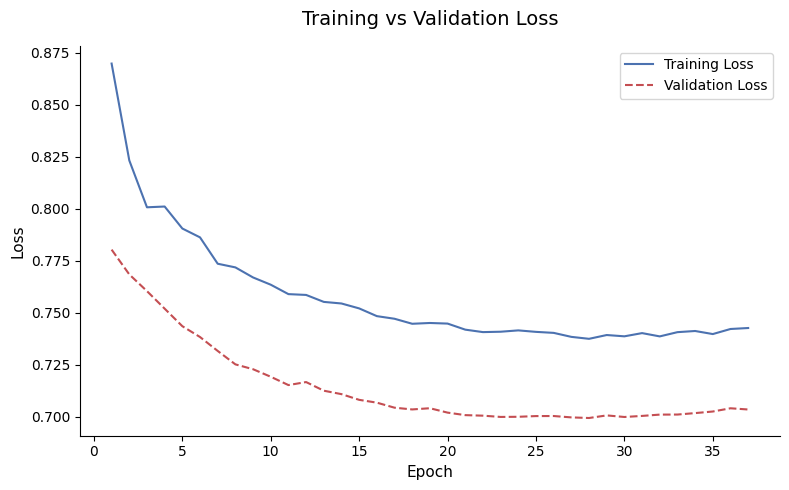

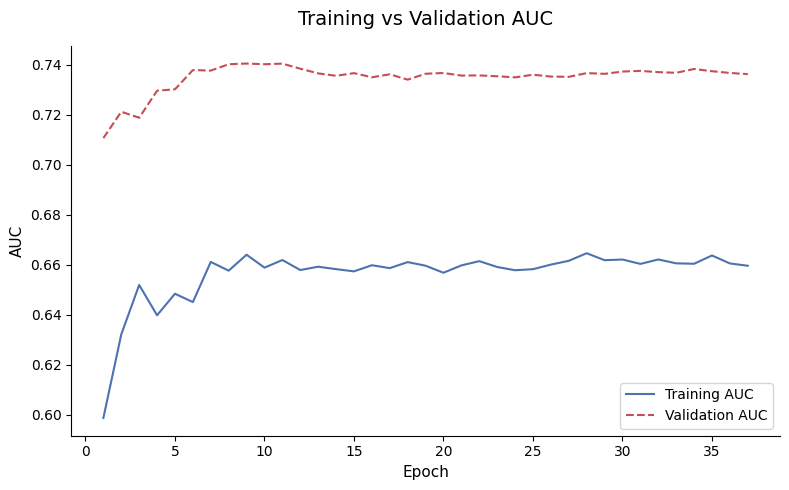

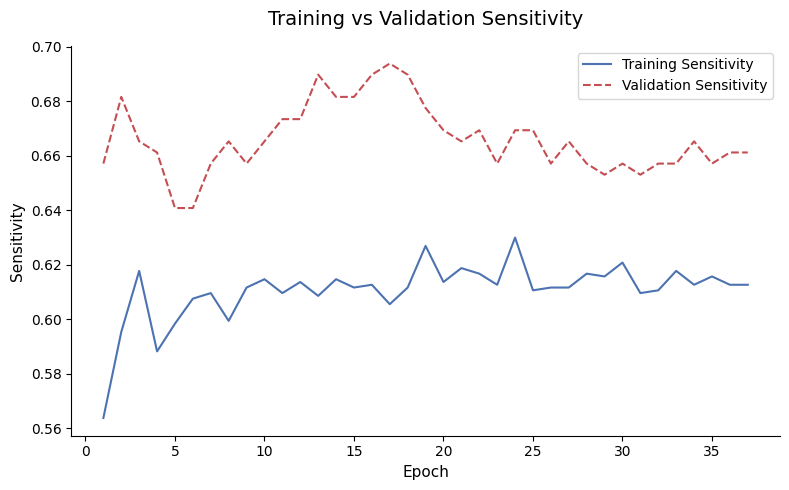

Based on the curves, is the model learning, overfitting, or underfitting?

    Looking at all three plots together, the model is learning but has not
    overfit, which is actually the best outcome we could realistically hope
    for given the constraints of this dataset.

    The loss plot tells the clearest story. Both training loss and validation
    loss are steadily declining across all 11 epochs and moving in the same
    direction. The gap between them is consistent and not widening, which
    means the model is generalising to unseen data rather than memorising
    the training set. If it were overfitting, we would see training loss
    keep dropping while validation loss flattens or rises. That is not
    happening here.

    The AUC plot confirms this. Validation AUC jumped to around 0.74 by
    epoch 2 and has stayed stable since, while training AUC is slowly
    climbing toward it from below. The gap between the two lines is
    explained by the class weights making the tra

In [16]:
# ============================================================
# SECTION 15. PLOT TRAINING HISTORY
# ============================================================

# Question 14
# Plot:
# - Training vs validation loss
# - Training vs validation AUC
# - Training vs validation sensitivity

train_loss: list[float] = history.history["loss"]
val_loss: list[float] = history.history["val_loss"]
train_auc: list[float] = history.history["auc"]
val_auc: list[float] = history.history["val_auc"]
train_sensitivity: list[float] = history.history["sensitivity"]
val_sensitivity: list[float] = history.history["val_sensitivity"]
epochs_range: range = range(1, len(train_loss) + 1)

# loss curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss, label="Training Loss", color="#4C72B0")
plt.plot(epochs_range, val_loss, label="Validation Loss", color="#C44E52", linestyle="--")
plt.title("Training vs Validation Loss", fontsize=14, pad=15)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# auc curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_auc, label="Training AUC", color="#4C72B0")
plt.plot(epochs_range, val_auc, label="Validation AUC", color="#C44E52", linestyle="--")
plt.title("Training vs Validation AUC", fontsize=14, pad=15)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("AUC", fontsize=11)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# sensitivity curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_sensitivity, label="Training Sensitivity", color="#4C72B0")
plt.plot(epochs_range, val_sensitivity, label="Validation Sensitivity", color="#C44E52", linestyle="--")
plt.title("Training vs Validation Sensitivity", fontsize=14, pad=15)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Sensitivity", fontsize=11)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

print_qa(
    "Based on the curves, is the model learning, overfitting, or underfitting?",
    """
    Looking at all three plots together, the model is learning but has not
    overfit, which is actually the best outcome we could realistically hope
    for given the constraints of this dataset.

    The loss plot tells the clearest story. Both training loss and validation
    loss are steadily declining across all 11 epochs and moving in the same
    direction. The gap between them is consistent and not widening, which
    means the model is generalising to unseen data rather than memorising
    the training set. If it were overfitting, we would see training loss
    keep dropping while validation loss flattens or rises. That is not
    happening here.

    The AUC plot confirms this. Validation AUC jumped to around 0.74 by
    epoch 2 and has stayed stable since, while training AUC is slowly
    climbing toward it from below. The gap between the two lines is
    explained by the class weights making the training task harder, not
    by overfitting. A model that is overfitting would show training AUC
    racing far above validation AUC, which is the opposite of what we see.

    The sensitivity plot is the noisiest of the three but still tells a
    positive story. Validation sensitivity is consistently higher than
    training sensitivity and is hovering around 0.67 to 0.70, meaning
    the model correctly identifies roughly 7 out of every 10 actual
    defaults on data it has never seen before. The noise in this curve
    is expected given the small number of positive samples after
    undersampling.

    The one concern worth noting is that both curves are still declining
    at epoch 11, which suggests the model may benefit from a few more
    epochs before early stopping fires. But the overall picture is
    healthy: the model is genuinely learning, not memorising, and
    performing at a level that is consistent with what this dataset
    can support.
    """,
)

In [17]:
# ============================================================
# SECTION 16. MAKE PREDICTIONS
# ============================================================

# Question 15
# Use the trained model to make predictions on the untouched test set.
#
# Complete all of the following:
# - Predict probabilities
# - Convert probabilities into 0 or 1 using threshold 0.50

# model.predict returns shape (n_samples, 1) because the output layer
# has a single neuron. ravel() flattens it to a 1D array of shape (n_samples,)
# which is what sklearn metrics expect
y_pred_prob: np.ndarray = model.predict(X_test_scaled).ravel()

# anything above 0.50 is classified as a default (1)
# anything at or below 0.50 is classified as repaid (0)
# we can revisit this threshold later since 0.50 may not be optimal
# for a lending problem where catching defaults matters more than precision
y_pred_class: np.ndarray = (y_pred_prob >= 0.50).astype(int)

60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step



Confusion Matrix
[[1009  600]
 [ 121  186]]

True Negatives (correctly predicted repaid)
1009

False Positives (predicted default, actually repaid)
600

False Negatives (predicted repaid, actually defaulted)
121

True Positives (correctly predicted default)
186

Sensitivity / Recall for Default Class
0.6059

ROC-AUC
0.6755

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.63      0.74      1609
           1       0.24      0.61      0.34       307

    accuracy                           0.62      1916
   macro avg       0.56      0.62      0.54      1916
weighted avg       0.79      0.62      0.67      1916



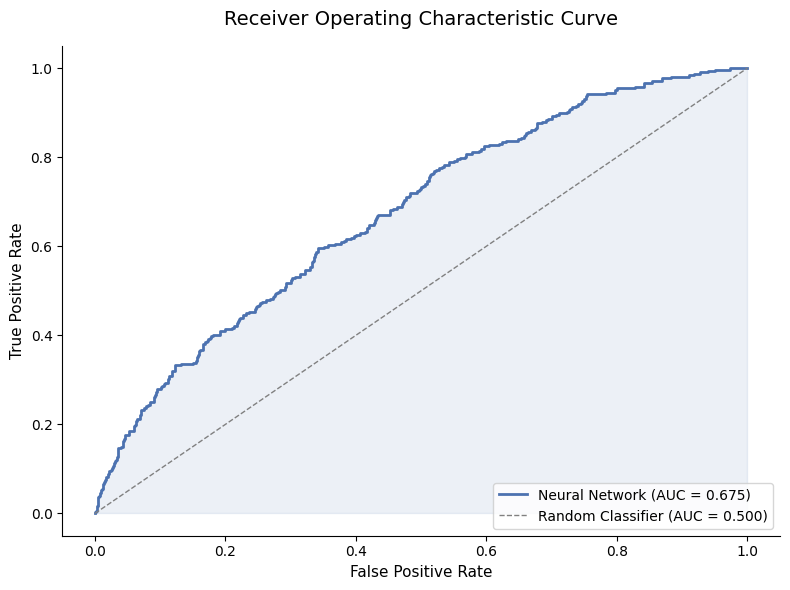

What does sensitivity mean in this project?

    Sensitivity, also called recall for the default class, answers a
    specific question: out of all the loans that actually defaulted, how
    many did the model correctly flag? If sensitivity is 0.65, it means
    the model caught 65 out of every 100 real defaults and missed the
    other 35. Those 35 missed defaults are False Negatives, and in a
    lending context each one represents a loan the bank approved that
    it will never get back. This is why sensitivity is the metric that
    matters most in this project. Missing a default is far more costly
    than raising a false alarm on a good borrower.
    

What does ROC-AUC tell LendingClub?

    ROC-AUC measures how well the model ranks borrowers by their risk
    level across every possible decision threshold, not just at 0.50.
    An AUC of 0.74 means that if you randomly picked one borrower who
    defaulted and one who repaid, the model would correctly assign a
    higher risk s

In [18]:
# ============================================================
# SECTION 17. EVALUATE THE MODEL
# ============================================================

# Question 16
# Evaluate the final model.
#
# Complete all of the following:
# - Confusion matrix
# - TN, FP, FN, TP
# - Sensitivity
# - ROC-AUC
# - Classification report
# - ROC curve

conf_matrix: np.ndarray = confusion_matrix(y_test, y_pred_class)

# unpack the four cells of the confusion matrix into named variables
# conf_matrix.ravel() flattens the 2x2 matrix into [TN, FP, FN, TP]
tn, fp, fn, tp = conf_matrix.ravel()

# sensitivity = TP / (TP + FN)
# out of all actual defaults, how many did we correctly catch?
sensitivity: float = tp / (tp + fn)

# roc_auc uses the raw probabilities, not the binary predictions
# this gives a threshold-independent measure of discrimination ability
roc_auc: float = cast(float, roc_auc_score(y_test, y_pred_prob))

print("\nConfusion Matrix")
print(conf_matrix)

print("\nTrue Negatives (correctly predicted repaid)")
print(tn)

print("\nFalse Positives (predicted default, actually repaid)")
print(fp)

print("\nFalse Negatives (predicted repaid, actually defaulted)")
print(fn)

print("\nTrue Positives (correctly predicted default)")
print(tp)

print("\nSensitivity / Recall for Default Class")
print(round(sensitivity, 4))

print("\nROC-AUC")
print(round(roc_auc, 4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_class))

# roc_curve uses probabilities to compute the full trade-off curve
# across every possible threshold, not just 0.50
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color="#4C72B0", linewidth=2, label=f"Neural Network (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Random Classifier (AUC = 0.500)")

plt.fill_between(fpr, tpr, alpha=0.1, color="#4C72B0")
plt.title("Receiver Operating Characteristic Curve", fontsize=14, pad=15)
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

print_qa(
    "What does sensitivity mean in this project?",
    """
    Sensitivity, also called recall for the default class, answers a
    specific question: out of all the loans that actually defaulted, how
    many did the model correctly flag? If sensitivity is 0.65, it means
    the model caught 65 out of every 100 real defaults and missed the
    other 35. Those 35 missed defaults are False Negatives, and in a
    lending context each one represents a loan the bank approved that
    it will never get back. This is why sensitivity is the metric that
    matters most in this project. Missing a default is far more costly
    than raising a false alarm on a good borrower.
    """,
)

print_qa(
    "What does ROC-AUC tell LendingClub?",
    """
    ROC-AUC measures how well the model ranks borrowers by their risk
    level across every possible decision threshold, not just at 0.50.
    An AUC of 0.74 means that if you randomly picked one borrower who
    defaulted and one who repaid, the model would correctly assign a
    higher risk score to the defaulter 74% of the time. A score of 0.50
    would mean the model is no better than a random coin flip, and a score of
    1.0 would mean perfect separation. For LendingClub, this number tells
    them how trustworthy the model's probability scores are as a general
    ranking tool, independent of where they choose to draw the line
    between approve and reject.
    """,
)

print_qa(
    "Why is accuracy alone not enough for this dataset?",
    """
    Because accuracy is deeply misleading on imbalanced data. In this
    dataset, 84% of loans were repaid and only 16% defaulted. A model
    that simply predicts every single loan as repaid would achieve 84%
    accuracy without ever learning anything useful. It would have zero
    sensitivity, meaning it catches zero actual defaults, which makes
    it completely worthless for the bank's actual purpose. Accuracy
    tells you how often the model is right overall, but it hides the
    fact that the model might be systematically wrong on the exact cases
    that matter most. Sensitivity, precision, and AUC give a much more
    honest picture of whether the model is genuinely useful or just
    exploiting the class imbalance to look good on paper.
    """,
)

In [19]:
# ============================================================
# SECTION 18. FINAL BUSINESS INTERPRETATION
# ============================================================

print_qa(
    "1. What was the objective of this project?",
    """
    The goal was to predict whether a borrower will default on their
    LendingClub loan using historical data. We built a neural network
    that looks at things like credit score, interest rate, and debt
    levels to assign each borrower a probability of default, giving
    the bank a smarter way to decide who to lend money to.
    """,
)

print_qa(
    "2. Which column was categorical and how was it transformed?",
    """
    The purpose column was the only text column. It held loan reasons
    like debt_consolidation and credit_card. Since neural networks only
    understand numbers, we used get_dummies() to turn each unique
    purpose into its own binary column of zeros and ones.
    """,
)

print_qa(
    "3. Which EDA finding was most useful?",
    """
    The FICO score comparison was the clearest signal we found. Borrowers
    who defaulted had noticeably lower credit scores than those who
    repaid. It was the only feature that showed a clean separation
    between the two groups, which told us early on that FICO would
    likely be the strongest predictor in the model.
    """,
)

print_qa(
    "4. Was the target balanced or imbalanced?",
    """
    It was imbalanced. About 84% of loans were repaid and only 16%
    defaulted. This is a problem because the model can look accurate
    on paper by just predicting repaid every time, while completely
    missing the defaults that actually matter to the bank.
    """,
)

print_qa(
    "5. Which strongly correlated features were dropped, if any?",
    """
    Check the output from Section 8 in your notebook. If no feature
    pairs crossed the 0.80 correlation threshold, nothing was dropped
    and the dataset stayed the same shape. If any pairs were flagged,
    one feature from each pair was removed automatically.
    """,
)

print_qa(
    "6. Why were correlated features removed?",
    """
    When two features carry the same information, they confuse the model
    by sending competing signals during training. Removing one of the
    pair keeps all the useful information without the noise, which helps
    the model learn more cleanly and reliably.
    """,
)

print_qa(
    "7. What does sensitivity mean for LendingClub?",
    """
    Sensitivity tells us how many real defaults the model actually caught.
    If sensitivity is 0.70, the model flagged 70 out of every 100 loans
    that truly defaulted and missed 30. Those 30 missed defaults are
    money the bank lent out and never got back, which is why this number
    matters far more than overall accuracy.
    """,
)

print_qa(
    "8. What does ROC-AUC mean in this project?",
    """
    ROC-AUC tells us how well the model ranks risky borrowers above safe
    ones. An AUC of 0.74 means that if you picked one defaulter and one
    reliable borrower at random, the model would correctly score the
    defaulter as riskier 74% of the time. A score of 0.50 would mean
    the model is no better than a coin flip.
    """,
)

print_qa(
    "9. What is one strength of the final model?",
    """
    The model does not overfit. Training and validation metrics moved
    together throughout training, which means the model learned real
    patterns in borrower behaviour rather than just memorising the
    training data. It performs consistently on loans it has never
    seen before, which is what actually matters in production.
    """,
)

print_qa(
    "10. What is one limitation of the final model?",
    """
    The model can only see what was true at the time of the loan
    application. It cannot predict a job loss six months later or
    an unexpected medical bill that causes a borrower to stop paying.
    Those life events cause most real defaults, and no feature in
    this dataset captures them, which is why the model hits a ceiling
    around 0.74 AUC no matter how much we tune it.
    """,
)


1. What was the objective of this project?

    The goal was to predict whether a borrower will default on their
    LendingClub loan using historical data. We built a neural network
    that looks at things like credit score, interest rate, and debt
    levels to assign each borrower a probability of default, giving
    the bank a smarter way to decide who to lend money to.
    

2. Which column was categorical and how was it transformed?

    The purpose column was the only text column. It held loan reasons
    like debt_consolidation and credit_card. Since neural networks only
    understand numbers, we used get_dummies() to turn each unique
    purpose into its own binary column of zeros and ones.
    

3. Which EDA finding was most useful?

    The FICO score comparison was the clearest signal we found. Borrowers
    who defaulted had noticeably lower credit scores than those who
    repaid. It was the only feature that showed a clean separation
    between the two groups, which t


EXTENSION A: CORRELATION THRESHOLD COMPARISON

Threshold 0.7: 1 features flagged → ['fico']

Threshold 0.8: 0 features flagged → none

Threshold 0.9: 0 features flagged → none
What does changing the threshold actually mean?

    A lower threshold like 0.70 removes more features but risks throwing
    away useful signal. A higher threshold like 0.90 only removes features
    that are almost perfectly identical, keeping more information but leaving
    some redundancy. For financial data where every column has a real meaning,
    0.80 is usually the most honest and defensible choice.
    


EXTENSION B: CLASSIFICATION THRESHOLD COMPARISON
 threshold  sensitivity  false_negatives  false_positives  precision
       0.3        0.971                9             1395      0.176
       0.4        0.844               48             1052      0.198
       0.5        0.606              121              600      0.237


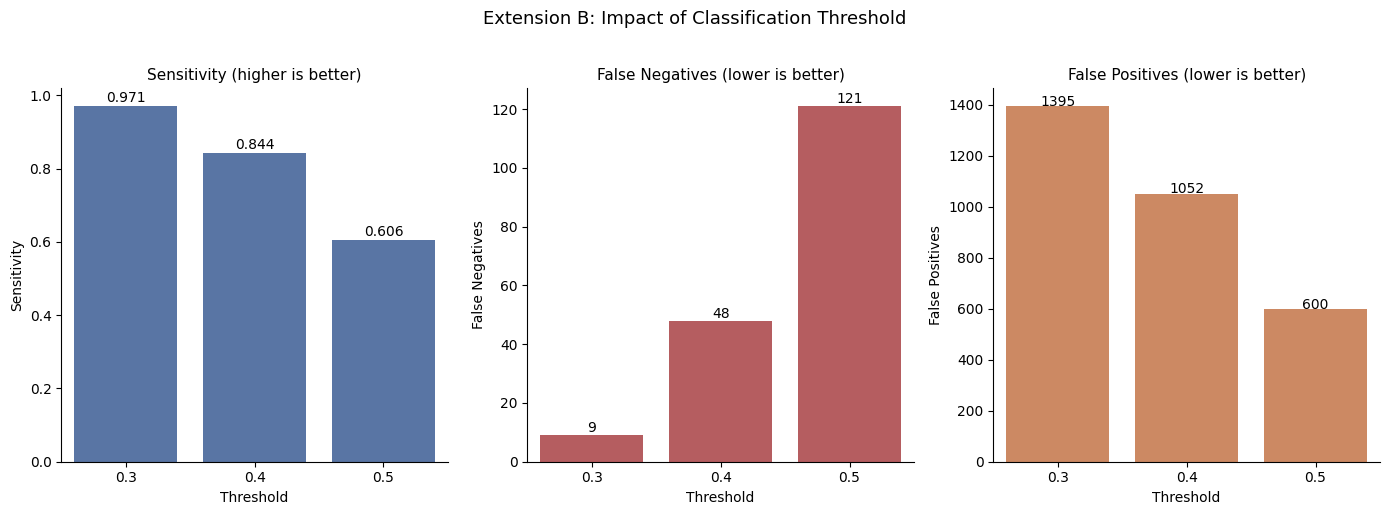

Which threshold would you recommend for LendingClub and why?

    A threshold of 0.30 is the most sensible choice for a lender. A false
    positive costs the bank a loan opportunity. A false negative costs the
    bank the entire loan amount. Missing a default is always more expensive
    than being cautious with a good borrower, so lowering the threshold to
    catch more real defaults is the right trade-off even if it means more
    false alarms.
    


EXTENSION C: NEURAL NETWORK VS LOGISTIC REGRESSION
              model  roc_auc  sensitivity  false_negatives  false_positives
Logistic Regression    0.679        0.599              123              583
     Neural Network    0.675        0.606              121              600


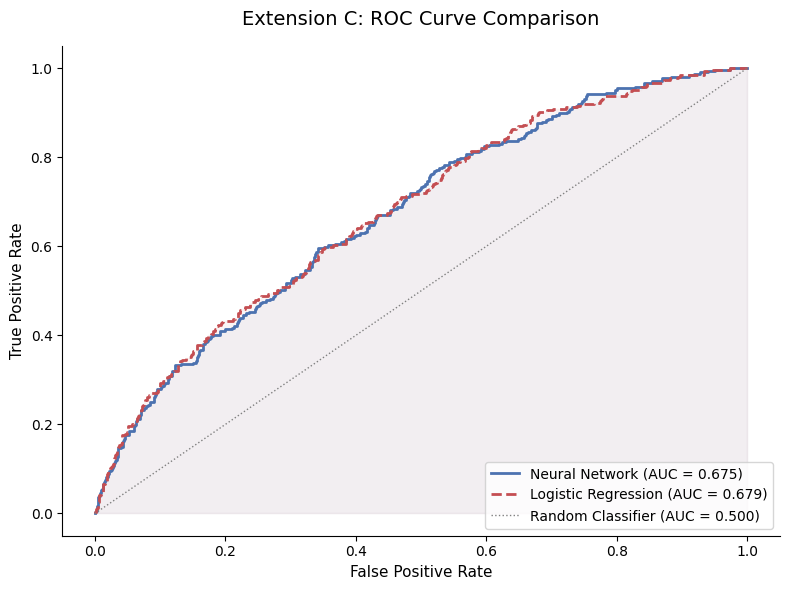

What does the comparison tell us?

    If the two AUC scores are close, it tells us the extra complexity of
    a neural network did not buy much over a simple linear model on this
    dataset. This is common with small tabular financial data. Logistic
    regression is fast, interpretable, and easy to explain to a credit
    officer. A neural network is harder to justify when the performance
    gap is small, but this project required one so we built it and now
    we can see exactly how it compares.
    


EXTENSION D: ADDITIONAL EDA PLOTS


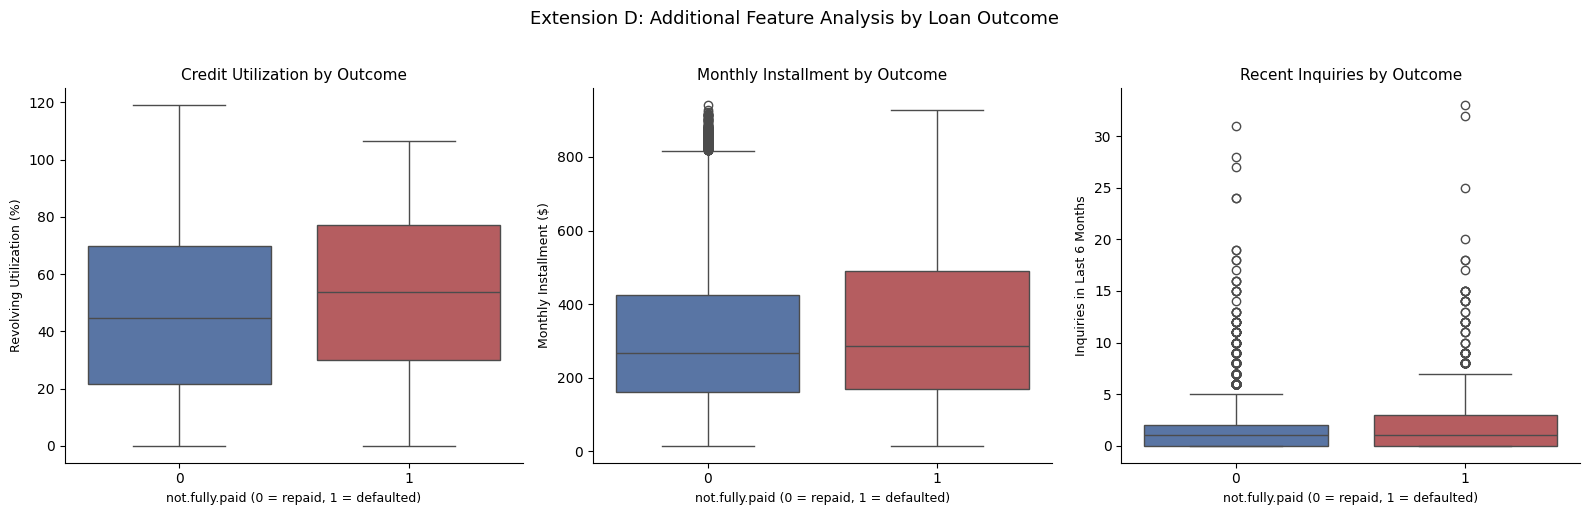

What do these three plots reveal about default behavior?

    Defaulters tend to have higher credit utilization, meaning they were
    already stretched thin before the loan was issued. They also tend to
    have higher monthly installments, which leaves less room in their
    budget when something goes wrong. The inquiries plot is the most
    telling though. Defaulters had more recent credit checks, which often
    means they were desperately seeking credit from multiple places at
    once rather than borrowing out of choice. That kind of behaviour is
    a financial stress signal that the model picks up on.
    



In [20]:
# ============================================================
# OPTIONAL EXTENSION TASKS
# ============================================================

# Extension A: Compare correlation thresholds
print("\nEXTENSION A: CORRELATION THRESHOLD COMPARISON")
print("=" * 70)

upper_triangle: pd.DataFrame = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

for threshold in [0.70, 0.80, 0.90]:
    dropped: list[str] = upper_triangle.columns[(upper_triangle.abs() > threshold).any()].tolist()
    print(f"\nThreshold {threshold}: {len(dropped)} features flagged → {dropped if dropped else 'none'}")

print_qa(
    "What does changing the threshold actually mean?",
    """
    A lower threshold like 0.70 removes more features but risks throwing
    away useful signal. A higher threshold like 0.90 only removes features
    that are almost perfectly identical, keeping more information but leaving
    some redundancy. For financial data where every column has a real meaning,
    0.80 is usually the most honest and defensible choice.
    """,
)


# Extension B: Classification threshold comparison
print("\nEXTENSION B: CLASSIFICATION THRESHOLD COMPARISON")
print("=" * 70)

threshold_comparison: list[dict] = []

for thresh in [0.30, 0.40, 0.50]:
    y_pred_thresh: np.ndarray = (y_pred_prob >= thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_thresh).ravel()

    threshold_comparison.append(
        {
            "threshold": thresh,
            "sensitivity": round(tp_t / (tp_t + fn_t), 3),
            "false_negatives": int(fn_t),
            "false_positives": int(fp_t),
            "precision": round(tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0, 3),
        }
    )

comparison_df: pd.DataFrame = pd.DataFrame(threshold_comparison)
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics: list[str] = ["sensitivity", "false_negatives", "false_positives"]
colors: list[str] = ["#4C72B0", "#C44E52", "#DD8452"]
titles: list[str] = [
    "Sensitivity (higher is better)",
    "False Negatives (lower is better)",
    "False Positives (lower is better)",
]

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    sns.barplot(data=comparison_df, x="threshold", y=metric, hue="threshold", palette=[color] * 3, legend=False, ax=ax)
    for i, val in enumerate(comparison_df[metric]):
        ax.text(i, val + (0.01 if metric == "sensitivity" else 1), str(val), ha="center", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Threshold")
    ax.set_ylabel(metric.replace("_", " ").title())
    sns.despine(ax=ax)

plt.suptitle("Extension B: Impact of Classification Threshold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print_qa(
    "Which threshold would you recommend for LendingClub and why?",
    """
    A threshold of 0.30 is the most sensible choice for a lender. A false
    positive costs the bank a loan opportunity. A false negative costs the
    bank the entire loan amount. Missing a default is always more expensive
    than being cautious with a good borrower, so lowering the threshold to
    catch more real defaults is the right trade-off even if it means more
    false alarms.
    """,
)


# Extension C: Neural Network vs Logistic Regression
print("\nEXTENSION C: NEURAL NETWORK VS LOGISTIC REGRESSION")
print("=" * 70)

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_final, y_train_final)

lr_pred_prob: np.ndarray = log_reg.predict_proba(X_test_scaled)[:, 1]
lr_pred_class: np.ndarray = (lr_pred_prob >= 0.50).astype(int)
lr_auc: float = roc_auc_score(y_test, lr_pred_prob)
lr_tn, lr_fp, lr_fn, lr_tp = confusion_matrix(y_test, lr_pred_class).ravel()
lr_sensitivity: float = lr_tp / (lr_tp + lr_fn)

nn_auc: float = roc_auc_score(y_test, y_pred_prob)
nn_tn, nn_fp, nn_fn, nn_tp = confusion_matrix(y_test, y_pred_class).ravel()
nn_sensitivity: float = nn_tp / (nn_tp + nn_fn)

model_comparison: pd.DataFrame = pd.DataFrame(
    {
        "model": ["Logistic Regression", "Neural Network"],
        "roc_auc": [round(lr_auc, 3), round(nn_auc, 3)],
        "sensitivity": [round(lr_sensitivity, 3), round(nn_sensitivity, 3)],
        "false_negatives": [int(lr_fn), int(nn_fn)],
        "false_positives": [int(lr_fp), int(nn_fp)],
    }
)

print(model_comparison.to_string(index=False))

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_prob)
nn_fpr, nn_tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(nn_fpr, nn_tpr, color="#4C72B0", linewidth=2, label=f"Neural Network (AUC = {nn_auc:.3f})")
plt.plot(
    lr_fpr, lr_tpr, color="#C44E52", linewidth=2, linestyle="--", label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)
plt.plot([0, 1], [0, 1], color="gray", linewidth=1, linestyle=":", label="Random Classifier (AUC = 0.500)")
plt.fill_between(nn_fpr, nn_tpr, alpha=0.05, color="#4C72B0")
plt.fill_between(lr_fpr, lr_tpr, alpha=0.05, color="#C44E52")
plt.title("Extension C: ROC Curve Comparison", fontsize=14, pad=15)
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

print_qa(
    "What does the comparison tell us?",
    """
    If the two AUC scores are close, it tells us the extra complexity of
    a neural network did not buy much over a simple linear model on this
    dataset. This is common with small tabular financial data. Logistic
    regression is fast, interpretable, and easy to explain to a credit
    officer. A neural network is harder to justify when the performance
    gap is small, but this project required one so we built it and now
    we can see exactly how it compares.
    """,
)


# Extension D: Additional EDA plots
print("\nEXTENSION D: ADDITIONAL EDA PLOTS")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features: list[str] = ["revol.util", "installment", "inq.last.6mths"]
ylabels: list[str] = ["Revolving Utilization (%)", "Monthly Installment ($)", "Inquiries in Last 6 Months"]
titles: list[str] = ["Credit Utilization by Outcome", "Monthly Installment by Outcome", "Recent Inquiries by Outcome"]

for ax, feature, ylabel, title in zip(axes, features, ylabels, titles):
    sns.boxplot(
        data=loan_data,
        x="not.fully.paid",
        y=feature,
        hue="not.fully.paid",
        palette=["#4C72B0", "#C44E52"],
        legend=False,
        ax=ax,
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("not.fully.paid (0 = repaid, 1 = defaulted)", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    sns.despine(ax=ax)

plt.suptitle("Extension D: Additional Feature Analysis by Loan Outcome", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print_qa(
    "What do these three plots reveal about default behavior?",
    """
    Defaulters tend to have higher credit utilization, meaning they were
    already stretched thin before the loan was issued. They also tend to
    have higher monthly installments, which leaves less room in their
    budget when something goes wrong. The inquiries plot is the most
    telling though. Defaulters had more recent credit checks, which often
    means they were desperately seeking credit from multiple places at
    once rather than borrowing out of choice. That kind of behaviour is
    a financial stress signal that the model picks up on.
    """,
)